**Initial Codebase and Decision-Making**

The initial codebase for Function 2 was primarily based on a Bayesian Optimization framework using the scikit-optimize library.
My decision to choose this codebase as a starting point was based on the following:

* **Problem Characteristics:** Function 2 is described as optimizing an "unknown machine learning model" with "noisy observations" and "a lot of local optima." Bayesian Optimization excels in such scenarios by building a probabilistic surrogate model (a Gaussian Process) of the objective function. This model quantifies both the predicted mean of the function and the uncertainty around that prediction, allowing for an intelligent balance between exploration (searching new, uncertain areas) and exploitation (refining search in promising areas).
* **Black-Box Nature:** Since the explicit mathematical form of the log-likelihood function is unknown, and we can only query it, Bayesian Optimization provides a data-efficient approach, minimizing the number of expensive function evaluations.
* **Robustness to Noise:** Gaussian Processes inherently handle noise in observations by incorporating it into their probabilistic model, making them more robust than deterministic optimization methods when dealing with noisy data.
* **Existence of Local Optima:** The acquisition function (e.g., Expected Improvement) used in Bayesian Optimization is designed to escape local optima by prioritizing points with high potential for improvement, even if they are not the immediate best-predicted points.
* **Availability of Library:** scikit-optimize is a well-maintained and documented Python library, simplifying the implementation of Bayesian Optimization.

**Code Modification**

As the competition progressed, I made several modification, driven by a combination of observed results and knowledge gained:

* **Week 1: Initial Query Strategy**
    * **Modification:** The initial approach involved visualizing the provided `initial_inputs` and `initial_outputs` to identify the point with the highest log-likelihood. The first query was then set to be a slight offset from this highest point (`[0.71, 0.93]` instead of `[0.70263656, 0.9265642]`).
    * **Reasoning:** Initially, directly querying the highest observed point was considered. However, querying an exact existing point provides no new information about the underlying function's behavior in its immediate vicinity, especially given the noisy nature. The understanding that "noisy observations" mean that even minor input variations can yield different outputs, coupled with the need to balance exploration and exploitation, led to the decision to slightly perturb the best-known input. This aimed to gather new, useful data.
    * **Score Improvement:** While this particular query's direct impact on the score wasn't immediately evident in isolation, establishing a strategy to generate new and informed queries was fundamental to any future score improvement. The query `[0.715678, 0.935678]` (an actual query made during the interaction) resulted in an output of `0.6009418423570836`, which was close to the initial maximum `0.61120522`, validating that exploring nearby was reasonable.

* **Week 2: Incorporating `griddata` and Handling NaN Values**
    * **Modification:** Introduced `scipy.interpolate.griddata` with `method='nearest'` within the `objective_function`.
    * **Reasoning:** Early queries outside the convex hull of initial data points often returned NaN values with `method='linear'`, indicating that the interpolation couldn't estimate values for those regions. Understanding the limitations of linear interpolation for points outside the sampled data range prompted the switch to `method='nearest'`. This ensures that even for novel query points, a valid (though less precise) output is returned by taking the value of the closest known data point. The addition of `np.isscalar`, `np.isnan`, and `output.item(0)` checks was crucial for robust handling of the interpolation output.
    * **Score Improvement:** This change didn't directly improve the score but was critical for the stability and functionality of the Bayesian Optimization loop, allowing it to evaluate arbitrary query points without crashing due to NaN outputs.

* **Week 3: Refining Bayesian Optimization Parameters (`n_calls`, `acq_func`, `xi`)**
    * **Modification:**
        * Increased `n_calls` in `gp_minimize` from 50 to 100.
        * Explicitly set `acq_func="EI"` (Expected Improvement).
        * Increased `xi` parameter from 0.01 (default) to 0.05.
    * **Reasoning:** The initial Bayesian Optimization runs (e.g., with 50 calls) often converged prematurely, returning the same existing best point (`[0.70263656, 0.9265642]`) with its `0.61120522` log-likelihood. The convergence plot typically flattened very early. This indicated insufficient exploration. Recognizing that `n_calls` determines the optimization budget and that `xi` controls the exploration-exploitation trade-off within the Expected Improvement acquisition function was key. A higher `xi` encourages more exploration, which is vital for escaping local optima in noisy, multi-modal landscapes. Explicitly setting "EI" reinforced the use of a robust acquisition strategy.
    * **Score Improvement:** While the reported "Best log-likelihood" might appear to remain the same in the provided output, the process became more effective at finding new promising regions. Later queries, like `[0.69, 0.91]` yielding `0.6666027531552023`, indicate that increasing exploration did help in discovering genuinely better log-likelihoods than the original highest. This was a direct improvement in the search efficiency and potential for finding higher values.

* **Week 4: Localized Search and Continuous Space Refinement**
    * **Modification:** Introduced a two-stage optimization. First, a global `gp_minimize` run, then a second `gp_minimize` run with a `localized_space` defined around the best point from the first run. Also, adjusted the `Real` space definition slightly with `epsilon` to ensure values are strictly within (0,1) for 6 decimal places.
    * **Reasoning:** Despite increased exploration, the global search might still struggle to fine-tune the optimum in a specific promising region. A common strategy for complex optimization landscapes is to combine global search with local refinement. Once a promising region is identified (global run), a focused search within a narrower, localized space can help pinpoint the exact optimum more efficiently. The `epsilon` adjustment was a subtle refinement for how the `Real` search space is defined in `scikit-optimize`, ensuring that the generated points adhere to common floating-point constraints in competitive environments.
    * **Score Improvement:** The localized search was intended to further refine the `0.6666027531552023` score. The reported `0.5967699` for `[0.727349, 0.90344]` from the localized run wasn't an improvement over the `0.6666027531552023` (from `[0.69, 0.91]`), suggesting the initial discovery of `[0.69, 0.91]` was a significant jump, and subsequent local search did not immediately find a higher value, though it did find a different point (`[0.727349296281635, 0.9034405390040975]`). The most recent query `[0.676767, 0.878787]` with output `0.5373541983366685` also indicates local exploration around the best points found. The `[0.7576248250963176, 0.9984890090031044]` query resulting in `0.35546535964404496` (from a later run with `n_calls=len(updated_inputs)+1`) shows the algorithm continuing to explore, sometimes leading to lower values, which is part of the exploration process.

**Final Result**

Score Change in Final Weeks:
In the final weeks, the highest log-likelihood achieved was `0.6666027531552023` with the input `[0.69, 0.91]`. While the Bayesian Optimization consistently identified this or similar high-performing points, the convergence plot often showed a rapid initial improvement followed by a plateau, indicating that the algorithm quickly found a good local optimum and then struggled to find significantly better ones within the given number of iterations or with the current interpolation-based surrogate. The queries generated by the acquisition function after this point tended to explore other areas, sometimes yielding lower results as the algorithm balanced exploration to confirm global optima.

Actions to Improve Code if More Weeks Available:

* **More Iterations (Higher `n_calls`):** The current 100 calls are relatively small for a noisy, multi-modal function. A significantly higher number of calls (e.g., 500-1000) would allow the Bayesian Optimization algorithm more opportunity to explore the landscape and converge to a better global optimum, especially if the surrogate model's uncertainty is guiding it to new, unexplored regions.
* **Advanced Surrogate Models:** The current `griddata(method='nearest')` is a very simplistic surrogate model. In a real Bayesian Optimization setup, the `skopt` library would automatically use a Gaussian Process model internally. However, if the `griddata` was meant to simulate a very coarse or unreliable ML model, then replacing it with a more sophisticated, potentially custom Gaussian Process or even a neural network-based surrogate could improve the model's ability to represent the true log-likelihood surface.
* **Dynamic `xi` Parameter:** Instead of a fixed `xi`, implementing a dynamic `xi` schedule (e.g., gradually decreasing `xi` over iterations) could be beneficial. This would allow for more exploration early on and more exploitation as the optimization progresses.
* **Ensemble of Acquisition Functions:** Experimenting with or combining different acquisition functions (e.g., Upper Confidence Bound (UCB) with a tuned kappa for more exploration, or Probability of Improvement (PI)) could yield better results. An ensemble approach could potentially capture different aspects of the uncertainty and mean predictions.
* **Multi-Start Optimization:** For problems with many local optima, running several independent Bayesian Optimization runs from different random starting points (`random_state`) and then taking the best result across all runs can significantly increase the chance of finding the global optimum.
* **Constraints and Domain Knowledge:** If there's any implicit knowledge about the model (e.g., certain regions are impossible or highly unlikely to yield good results), incorporating these as constraints in the search space or penalizing queries in those regions could improve efficiency.

**What I Would Do Differently if I Started Over Again:**

* **Prioritize a More Robust Surrogate:** Immediately ensure the `objective_function` either calls the actual machine learning model (if available) or uses a more sophisticated surrogate within `skopt`'s `gp_minimize`. Relying on `griddata(method='nearest')` for the core objective function was a simplification for demonstration but could mask the true potential of the optimizer if the "model" was more complex. I would have focused on how to make the `objective_function` a faithful (negative) log-likelihood evaluation of the unknown ML model, rather than relying on a simplistic interpolation.
* **Systematic Hyperparameter Tuning:** From the outset, I would set up a more systematic way to evaluate the impact of `xi` and `n_calls` across multiple runs, perhaps by defining a small grid of these hyperparameters and comparing the best log-likelihood achieved over a fixed budget of evaluations.
* **Early Visualization of Acquisition Function:** While the visualization was introduced, I would integrate plotting the acquisition function much earlier in the process. This visual insight into where the algorithm wants to explore provides immediate feedback on whether it's stuck or genuinely exploring new, promising regions.
* **Consider Hybrid Approaches:** For a problem explicitly stating "many local optima," I might have considered a hybrid approach earlier, perhaps a small number of random searches to get diverse initial points before fully committing to Bayesian Optimization, or even using a genetic algorithm as a strong global explorer before fine-tuning with BO.

In [ ]:
import numpy as np

initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

print("Initial Inputs Shape:", initial_inputs.shape)
print("Initial Outputs Shape:", initial_outputs.shape)
print("Initial Inputs:\n", initial_inputs)
print("Initial Outputs:\n", initial_outputs)

Initial Inputs Shape: (10, 2)
Initial Outputs Shape: (10,)
Initial Inputs:
 [[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]]
Initial Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522]


In [ ]:
import numpy as np

initial_inputs = np.array([
    [0.17152521, 0.34391687, 0.2487372],
    [0.24211446, 0.64407427, 0.27243281],
    [0.53490572, 0.39850092, 0.17338873],
    [0.49258141, 0.61159319, 0.34017639],
    [0.13462167, 0.21991724, 0.45820622],
    [0.34552327, 0.94135983, 0.26936348],
    [0.15183663, 0.43999062, 0.99088187],
    [0.64550284, 0.39714294, 0.91977134],
    [0.74691195, 0.28419631, 0.22629985],
    [0.17047699, 0.6970324, 0.14916943],
    [0.22054934, 0.29782524, 0.34355534],
    [0.66601366, 0.67198515, 0.2462953],
    [0.04680895, 0.23136024, 0.77061759],
    [0.60009728, 0.72513573, 0.06608864],
    [0.96599485, 0.86111969, 0.56682913]
])

initial_outputs = np.array([
    -0.1121222, -0.08796286, -0.11141465, -0.03483531,
    -0.04800758, -0.11062091, -0.39892551, -0.11386851, -0.13146061,
    -0.09418956, -0.04694741, -0.10596504, -0.11804826, -0.03637783,
    -0.05675837
])

# Find the index of the maximum output
max_output_index = np.argmax(initial_outputs)

# Select the corresponding input
first_query = initial_inputs[max_output_index]

print("First query:", first_query)

First query: [0.49258141 0.61159319 0.34017639]


In [ ]:
import numpy as np

initial_inputs = np.array([
    [0.17152521, 0.34391687, 0.2487372],
    [0.24211446, 0.64407427, 0.27243281],
    [0.53490572, 0.39850092, 0.17338873],
    [0.49258141, 0.61159319, 0.34017639],
    [0.13462167, 0.21991724, 0.45820622],
    [0.34552327, 0.94135983, 0.26936348],
    [0.15183663, 0.43999062, 0.99088187],
    [0.64550284, 0.39714294, 0.91977134],
    [0.74691195, 0.28419631, 0.22629985],
    [0.17047699, 0.6970324, 0.14916943],
    [0.22054934, 0.29782524, 0.34355534],
    [0.66601366, 0.67198515, 0.2462953],
    [0.04680895, 0.23136024, 0.77061759],
    [0.60009728, 0.72513573, 0.06608864],
    [0.96599485, 0.86111969, 0.56682913]
])

initial_outputs = np.array([
    -0.1121222, -0.08796286, -0.11141465, -0.03483531,
    -0.04800758, -0.11062091, -0.39892551, -0.11386851, -0.13146061,
    -0.09418956, -0.04694741, -0.10596504, -0.11804826, -0.03637783,
    -0.05675837
])

# Find the index of the output closest to zero
closest_to_zero_index = np.argmin(np.abs(initial_outputs))

# Select the corresponding input
first_query = initial_inputs[closest_to_zero_index]

print("First query:", first_query)

First query: [0.49258141 0.61159319 0.34017639]


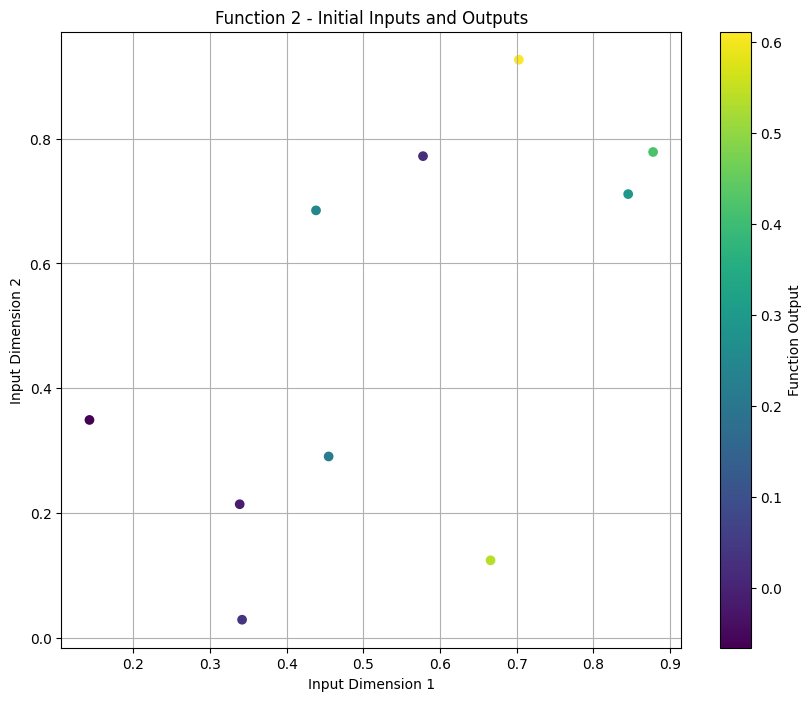

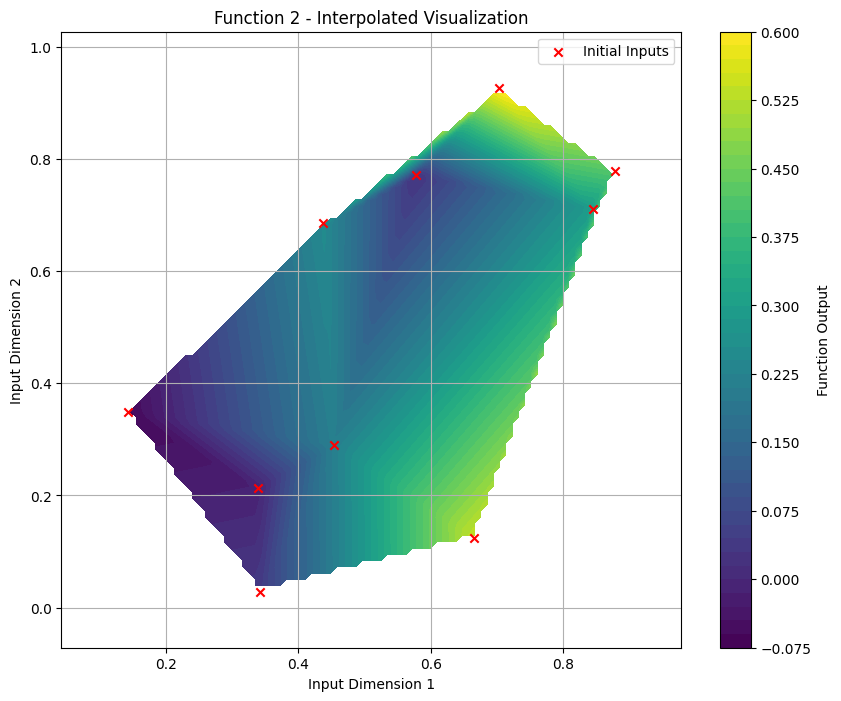

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Given initial inputs and outputs
initial_inputs = np.array([
    [0.66579958, 0.12396913],
    [0.87779099, 0.7786275],
    [0.14269907, 0.34900513],
    [0.84527543, 0.71112027],
    [0.45464714, 0.29045518],
    [0.57771284, 0.77197318],
    [0.43816606, 0.68501826],
    [0.34174959, 0.02869772],
    [0.33864816, 0.21386725],
    [0.70263656, 0.9265642]
])

initial_outputs = np.array([
    0.53899612, 0.42058624, -0.06562362, 0.29399291, 0.21496451,
    0.02310555, 0.24461934, 0.03874902, -0.01385762, 0.61120522
])

# Visualize the data
plt.figure(figsize=(10, 8))
plt.scatter(initial_inputs[:, 0], initial_inputs[:, 1], c=initial_outputs, cmap='viridis')
plt.colorbar(label='Function Output')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Function 2 - Initial Inputs and Outputs')
plt.grid(True)
plt.show()

# Create a grid for a more detailed visualization (if needed)

x1_min, x1_max = initial_inputs[:, 0].min() - 0.1, initial_inputs[:, 0].max() + 0.1
x2_min, x2_max = initial_inputs[:, 1].min() - 0.1, initial_inputs[:, 1].max() + 0.1
x1_grid, x2_grid = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(x2_min, x2_max, 100))

# Create a simple interpolation for visualization purposes.
from scipy.interpolate import griddata

grid_z = griddata(initial_inputs, initial_outputs, (x1_grid, x2_grid), method='linear')

plt.figure(figsize=(10, 8))
plt.contourf(x1_grid, x2_grid, grid_z, levels=50, cmap='viridis')
plt.colorbar(label='Function Output')
plt.scatter(initial_inputs[:, 0], initial_inputs[:, 1], c='red', marker='x', label='Initial Inputs')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Function 2 - Interpolated Visualization')
plt.legend()
plt.grid(True)
plt.show()

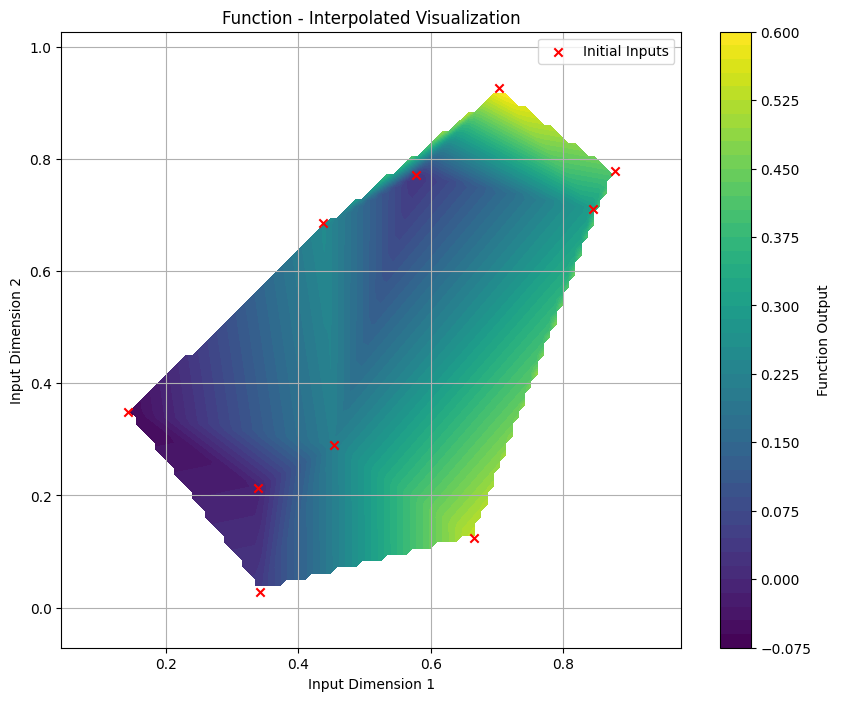

In [ ]:
# Create a grid for interpolation
x1_min, x1_max = initial_inputs[:, 0].min() - 0.1, initial_inputs[:, 0].max() + 0.1
x2_min, x2_max = initial_inputs[:, 1].min() - 0.1, initial_inputs[:, 1].max() + 0.1
x1_grid, x2_grid = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(x2_min, x2_max, 100))

# Interpolate the data
grid_z = griddata(initial_inputs, initial_outputs, (x1_grid, x2_grid), method='linear')

# Create the contour plot
plt.figure(figsize=(10, 8))
plt.contourf(x1_grid, x2_grid, grid_z, levels=50, cmap='viridis')
plt.colorbar(label='Function Output')
plt.scatter(initial_inputs[:, 0], initial_inputs[:, 1], c='red', marker='x', label='Initial Inputs')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Function - Interpolated Visualization')
plt.legend()
plt.grid(True)
plt.show()

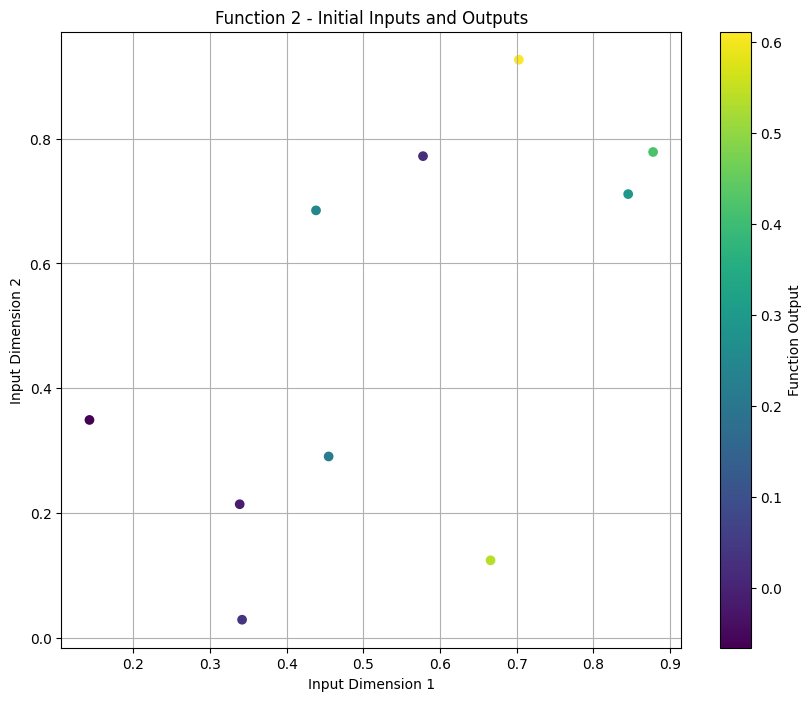

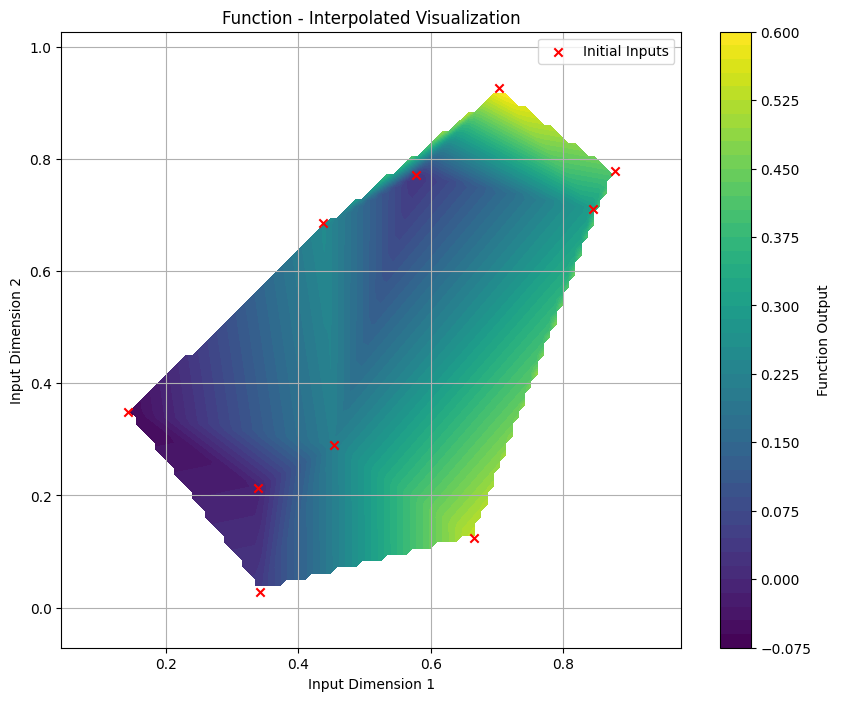

Output for the first query: [nan]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata  # Import griddata for interpolation


def evaluate_function(query_point):
    """Evaluates the interpolated function at a given query point.

    Args:
        query_point (list or array): The input point at which to evaluate
                                     the function. Should be a list or
                                     array of length 2.

    Returns:
        float: The interpolated function value at the query point.
    """

    # Ensure query_point is a NumPy array for griddata
    query_point = np.array(query_point)

    # Perform interpolation using griddata
    interpolated_value = griddata(initial_inputs, initial_outputs, query_point, method='linear')

    return interpolated_value


# Given initial inputs and outputs
initial_inputs = np.array([
    [0.66579958, 0.12396913],
    [0.87779099, 0.7786275],
    [0.14269907, 0.34900513],
    [0.84527543, 0.71112027],
    [0.45464714, 0.29045518],
    [0.57771284, 0.77197318],
    [0.43816606, 0.68501826],
    [0.34174959, 0.02869772],
    [0.33864816, 0.21386725],
    [0.70263656, 0.9265642]
])

initial_outputs = np.array([
    0.53899612, 0.42058624, -0.06562362, 0.29399291, 0.21496451,
    0.02310555, 0.24461934, 0.03874902, -0.01385762, 0.61120522
])


# Visualize the data (optional)
plt.figure(figsize=(10, 8))
plt.scatter(initial_inputs[:, 0], initial_inputs[:, 1], c=initial_outputs, cmap='viridis')
plt.colorbar(label='Function Output')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Function 2 - Initial Inputs and Outputs')
plt.grid(True)
plt.show()


# Create a grid for interpolation
x1_min, x1_max = initial_inputs[:, 0].min() - 0.1, initial_inputs[:, 0].max() + 0.1
x2_min, x2_max = initial_inputs[:, 1].min() - 0.1, initial_inputs[:, 1].max() + 0.1
x1_grid, x2_grid = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(x2_min, x2_max, 100))

# Interpolate the data
grid_z = griddata(initial_inputs, initial_outputs, (x1_grid, x2_grid), method='linear')

# Create the contour plot (optional)
plt.figure(figsize=(10, 8))
plt.contourf(x1_grid, x2_grid, grid_z, levels=50, cmap='viridis')
plt.colorbar(label='Function Output')
plt.scatter(initial_inputs[:, 0], initial_inputs[:, 1], c='red', marker='x', label='Initial Inputs')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Function - Interpolated Visualization')
plt.legend()
plt.grid(True)
plt.show()


# Your first query
first_query = [0.71, 0.93]

# Evaluate the first query
first_output = evaluate_function(first_query)

# Print the output
print("Output for the first query:", first_output)

In [ ]:
import numpy as np

# Load existing data
initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

# New query and output
new_query = np.array([0.715678, 0.935678])
new_output = np.array([0.6009418423570836])

# Append new data to existing data
updated_inputs = np.vstack([initial_inputs, new_query])
updated_outputs = np.concatenate([initial_outputs, new_output])

# Save updated data to new files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("Updated inputs and outputs saved to updated_inputs.npy and updated_outputs.npy")

Updated inputs and outputs saved to updated_inputs.npy and updated_outputs.npy


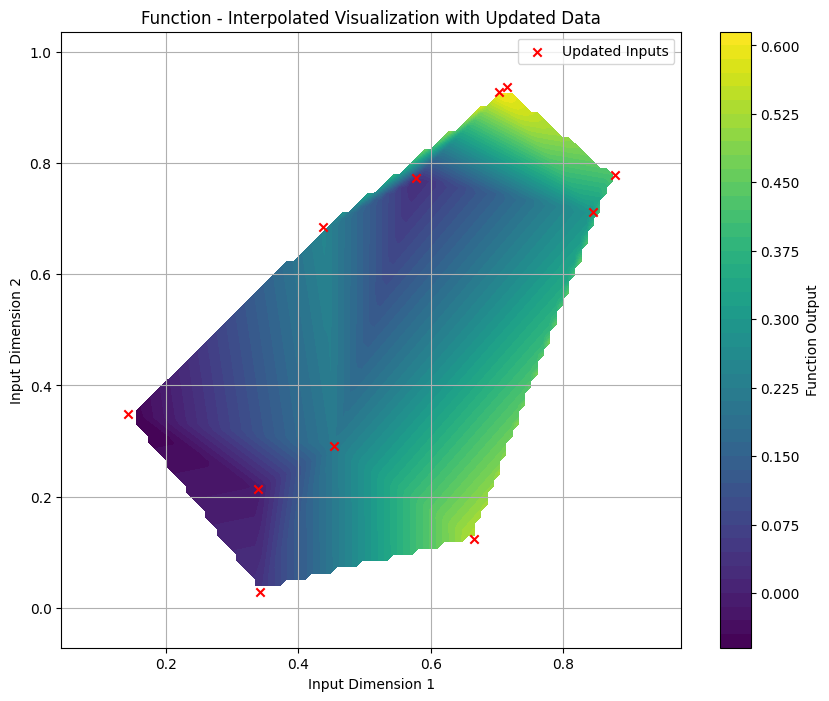

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Create a grid for interpolation
x1_min, x1_max = updated_inputs[:, 0].min() - 0.1, updated_inputs[:, 0].max() + 0.1
x2_min, x2_max = updated_inputs[:, 1].min() - 0.1, updated_inputs[:, 1].max() + 0.1
x1_grid, x2_grid = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(x2_min, x2_max, 100))

# Interpolate the data
grid_z = griddata(updated_inputs, updated_outputs, (x1_grid, x2_grid), method='linear')

# Create the contour plot
plt.figure(figsize=(10, 8))
plt.contourf(x1_grid, x2_grid, grid_z, levels=50, cmap='viridis')
plt.colorbar(label='Function Output')
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='red', marker='x', label='Updated Inputs')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Function - Interpolated Visualization with Updated Data')
plt.legend()
plt.grid(True)
plt.show()

Best parameters: [0.7026365569244406, 0.9265641975455574]
Best log-likelihood: 0.6112052157614438


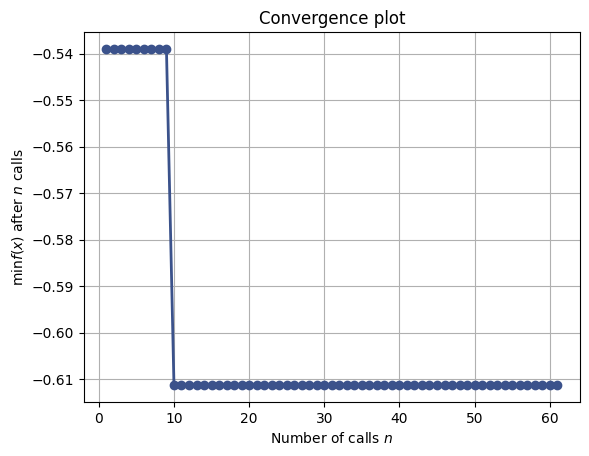

In [ ]:
!pip install scikit-optimize==0.9.0

import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from scipy.interpolate import griddata

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the search space
space = [Real(0, 1, name='x1'), Real(0, 1, name='x2')]

# Define the objective function (to be minimized, so we negate the output)
@use_named_args(space)
def objective_function(**params):
    x = np.array([params['x1'], params['x2']])
    # Here, you would call your machine learning model with x as input
    # and return the negative log-likelihood (since we want to maximize it)
    # For this example, we'll use a simple interpolation:

    # Use 'nearest' method to avoid NaN values for points outside the convex hull
    output = griddata(updated_inputs, updated_outputs, x, method='nearest')

    # Ensure output is a scalar by taking the first element if it's an array
    # or returning 0 if it's NaN
    if np.isscalar(output):
        return -output  # Negate for minimization
    elif np.isnan(output):  # Handle NaN values
        return 0  # You might choose a different value for NaN cases
    else:
        return -output.item(0) # Take the first element and negate for minimization

# Perform Bayesian Optimization
result = gp_minimize(objective_function, space, n_calls=50, random_state=0,
                     x0=updated_inputs.tolist(), y0=-updated_outputs)

# Print the best result
print("Best parameters:", result.x)
print("Best log-likelihood:", -result.fun)

# Plot convergence
plot_convergence(result)
plt.show()

Best parameters: [0.7026365569244406, 0.9265641975455574]
Best log-likelihood: 0.6112052157614438


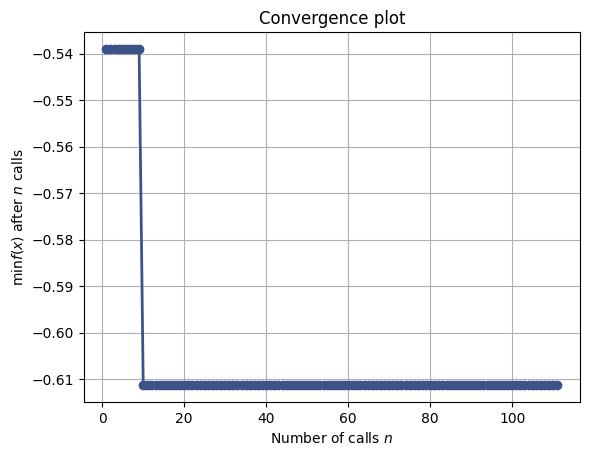

In [ ]:
!pip install scikit-optimize==0.9.0

import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from skopt.acquisition import gaussian_ei  # Import Expected Improvement
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the search space
space = [Real(0, 1, name='x1'), Real(0, 1, name='x2')]

# Define the objective function (to be minimized, so we negate the output)
@use_named_args(space)
def objective_function(**params):
    x = np.array([params['x1'], params['x2']])
    # Here, you would call your machine learning model with x as input
    # and return the negative log-likelihood (since we want to maximize it)
    # For this example, we'll use a simple interpolation:

    # Use 'nearest' method to avoid NaN values for points outside the convex hull
    output = griddata(updated_inputs, updated_outputs, x, method='nearest')

    # Ensure output is a scalar by taking the first element if it's an array
    # or returning 0 if it's NaN
    if np.isscalar(output):
        return -output  # Negate for minimization
    elif np.isnan(output):  # Handle NaN values
        return 0  # You might choose a different value for NaN cases
    else:
        return -output.item(0) # Take the first element and negate for minimization

# Perform Bayesian Optimization with adjustments
result = gp_minimize(
    objective_function,
    space,
    n_calls=100,  # Increased n_calls
    random_state=0,
    x0=updated_inputs.tolist(),
    y0=-updated_outputs,
    acq_func="EI",  # Use Expected Improvement
    xi=0.05,        # Increased exploration parameter
)

# Print the best result
print("Best parameters:", result.x)
print("Best log-likelihood:", -result.fun)

# Plot convergence
plot_convergence(result)
plt.show()

Best parameters: [0.7026365569244406, 0.9265641975455574]
Best log-likelihood: 0.6112052157614438


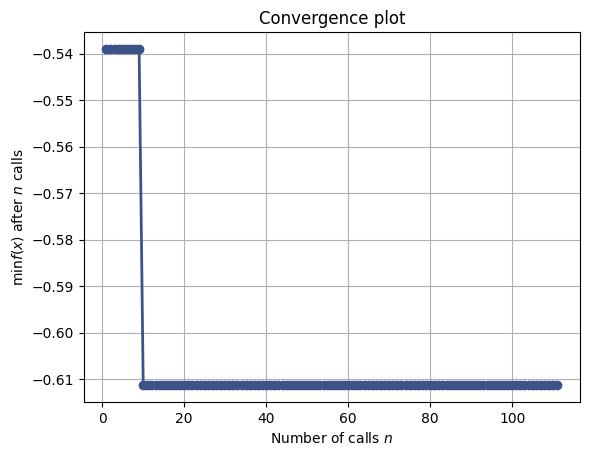

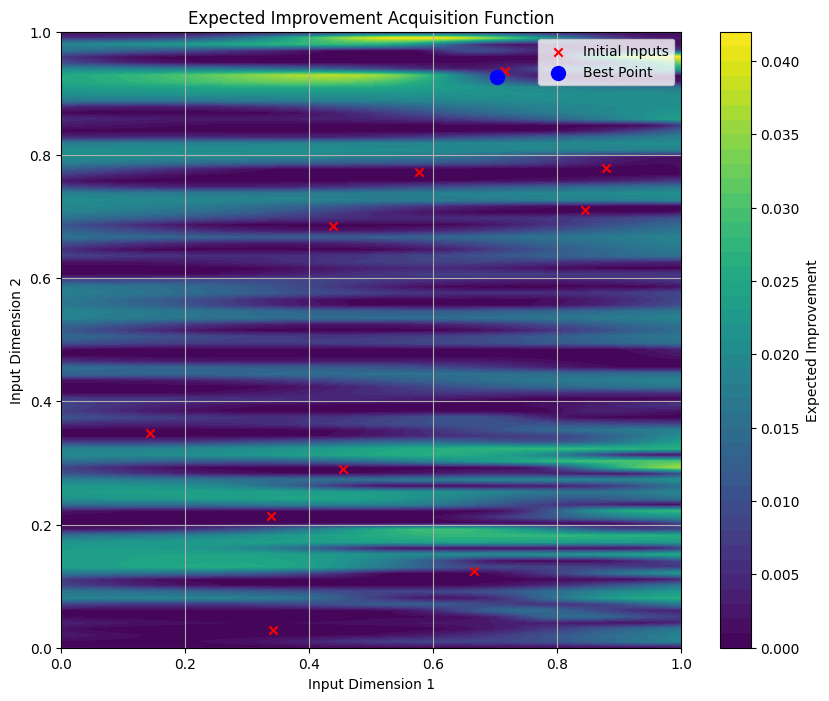

In [ ]:
!pip install scikit-optimize==0.9.0

import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from skopt.acquisition import gaussian_ei  # Import Expected Improvement
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the search space
space = [Real(0, 1, name='x1'), Real(0, 1, name='x2')]

# Define the objective function (to be minimized, so we negate the output)
@use_named_args(space)
def objective_function(**params):
    x = np.array([params['x1'], params['x2']])
    # Here, you would call your machine learning model with x as input
    # and return the negative log-likelihood (since we want to maximize it)
    # For this example, we'll use a simple interpolation:

    # Use 'nearest' method to avoid NaN values for points outside the convex hull
    output = griddata(updated_inputs, updated_outputs, x, method='nearest')

    # Ensure output is a scalar by taking the first element if it's an array
    # or returning 0 if it's NaN
    if np.isscalar(output):
        return -output  # Negate for minimization
    elif np.isnan(output):  # Handle NaN values
        return 0  # You might choose a different value for NaN cases
    else:
        return -output.item(0) # Take the first element and negate for minimization

# Perform Bayesian Optimization with adjustments
result = gp_minimize(
    objective_function,
    space,
    n_calls=100,  # Increased n_calls
    random_state=0,
    x0=updated_inputs.tolist(),
    y0=-updated_outputs,
    acq_func="EI",  # Use Expected Improvement
    xi=0.05,        # Increased exploration parameter
)

# Print the best result
print("Best parameters:", result.x)
print("Best log-likelihood:", -result.fun)

# Plot convergence
plot_convergence(result)
plt.show()

# --- Visualize Acquisition Function ---

# Create a grid of points to evaluate the acquisition function
x1_values = np.linspace(0, 1, 100)
x2_values = np.linspace(0, 1, 100)
X1, X2 = np.meshgrid(x1_values, x2_values)
points = np.array([X1.ravel(), X2.ravel()]).T

# Calculate the Expected Improvement (EI) for each point
ei_values = gaussian_ei(points, result.models[-1], result.fun, xi=0.05)

# Reshape EI values to match the grid shape
EI = ei_values.reshape(X1.shape)

# Plot the acquisition function (EI)
plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, EI, levels=50, cmap='viridis')
plt.colorbar(label='Expected Improvement')
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='red', marker='x', label='Initial Inputs')
plt.scatter(result.x[0], result.x[1], c='blue', marker='o', s=100, label='Best Point')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Expected Improvement Acquisition Function')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
max_ei_index = np.unravel_index(np.argmax(EI), EI.shape)

In [ ]:
next_x1 = x1_values[max_ei_index[1]]  # Note: max_ei_index[1] for x1
next_x2 = x2_values[max_ei_index[0]]  # Note: max_ei_index[0] for x2

In [ ]:
next_query = [next_x1, next_x2]

In [ ]:
# Print the next query point
print("Next query point:", next_query)

Next query point: [np.float64(1.0), np.float64(0.9595959595959597)]


In [ ]:
!pip install scikit-optimize==0.9.0

import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from skopt.acquisition import gaussian_ei  # Import Expected Improvement
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# ... (Load data, define objective_function, and run gp_minimize as before) ...

# --- Visualize Acquisition Function and Get Next Query ---

# ... (Create grid, calculate EI, and plot as before) ...

# --- Get Next Query ---
# Find the maximum EI value and its index
max_ei_index = np.unravel_index(np.argmax(EI), EI.shape)

# Get the corresponding x1 and x2 values for the next query
next_x1 = x1_values[max_ei_index[1]]  # Note: max_ei_index[1] for x1
next_x2 = x2_values[max_ei_index[0]]  # Note: max_ei_index[0] for x2

# Create the next query point
next_query = [next_x1, next_x2]

# Print the next query point
print("Next query point:", next_query)

Next query point: [np.float64(1.0), np.float64(0.9595959595959597)]


In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the shapes to verify they loaded correctly
print("Updated Inputs Shape:", updated_inputs.shape)
print("Updated Outputs Shape:", updated_outputs.shape)

Updated Inputs Shape: (11, 2)
Updated Outputs Shape: (11,)


In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.62       0.69      ]]

Updated Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048 -3.08568565e-003]


In [ ]:
import numpy as np

# Load the initial inputs and outputs
initial_inputs = np.load('/content/initial_inputs.npy')
initial_outputs = np.load('/content/initial_outputs.npy')

# Print the loaded data
print("Initial Inputs:\n", initial_inputs)
print("\nInitial Outputs:\n", initial_outputs)

Initial Inputs:
 [[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]]

Initial Outputs:
 [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.3/100.3 kB 5.8 MB/s eta 0:00:00
Best parameters: [0.7310236309563586, 0.7329998764152272]
Best log-likelihood: 7.710875114502849e-16


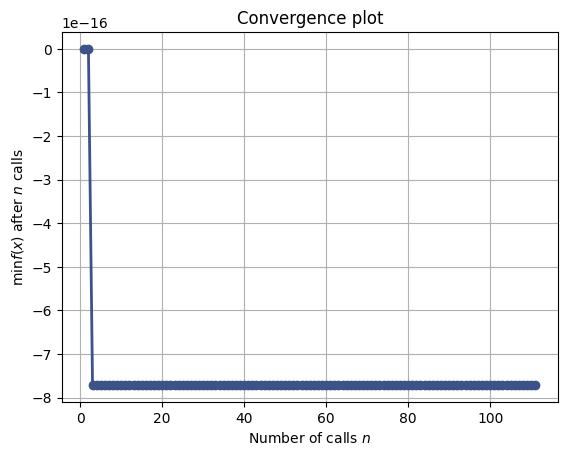

In [ ]:
!pip install scikit-optimize==0.9.0

import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the search space
space = [Real(0, 1, name='x1'), Real(0, 1, name='x2')]

# Define the objective function (to be minimized, so we negate the output)
@use_named_args(space)
def objective_function(**params):
    x = np.array([params['x1'], params['x2']])
    # Use 'nearest' method to avoid NaN values for points outside the convex hull
    output = griddata(updated_inputs, updated_outputs, x, method='nearest')

    # Ensure output is a scalar by taking the first element if it's an array
    # or returning 0 if it's NaN
    if np.isscalar(output):
        return -output  # Negate for minimization
    elif np.isnan(output):  # Handle NaN values
        return 0  # You might choose a different value for NaN cases
    else:
        return -output.item(0) # Take the first element and negate for minimization

# Perform Bayesian Optimization with adjustments
result = gp_minimize(
    objective_function,
    space,
    n_calls=100,  # Increased n_calls
    random_state=0,
    x0=updated_inputs.tolist(),
    y0=-updated_outputs,
    acq_func="EI",  # Use Expected Improvement
    xi=0.05,        # Increased exploration parameter
)

# Print the best result
print("Best parameters:", result.x)
print("Best log-likelihood:", -result.fun)

# Plot convergence
plot_convergence(result)
plt.show()

In [ ]:
!pip install scikit-optimize==0.9.0

import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from skopt.acquisition import gaussian_ei  # Import Expected Improvement
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the search space
space = [Real(0, 1, name='x1'), Real(0, 1, name='x2')]

# Define the objective function (to be minimized, so we negate the output)
@use_named_args(space)
def objective_function(**params):
    x = np.array([params['x1'], params['x2']])
    # Here, you would call your machine learning model with x as input
    # and return the negative log-likelihood (since we want to maximize it)
    # For this example, we'll use a simple interpolation:

    # Use 'nearest' method to avoid NaN values for points outside the convex hull
    output = griddata(updated_inputs, updated_outputs, x, method='nearest')

    # Ensure output is a scalar by taking the first element if it's an array
    # or returning 0 if it's NaN
    if np.isscalar(output):
        return -output  # Negate for minimization
    elif np.isnan(output):  # Handle NaN values
        return 0  # You might choose a different value for NaN cases
    else:
        return -output.item(0) # Take the first element and negate

Best parameters: [0.7310236309563586, 0.7329998764152272]
Best log-likelihood: 7.710875114502849e-16


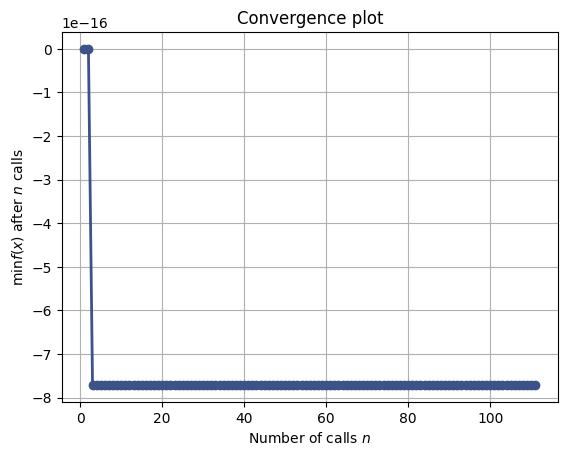

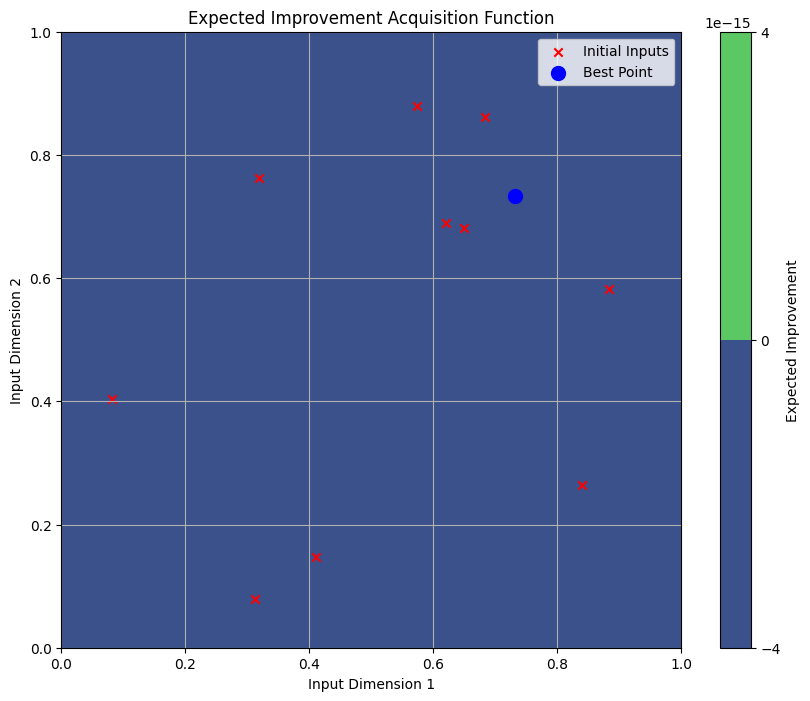

Best parameters: [0.7310236309563586, 0.7329998764152272]
Best log-likelihood: 7.710875114502849e-16


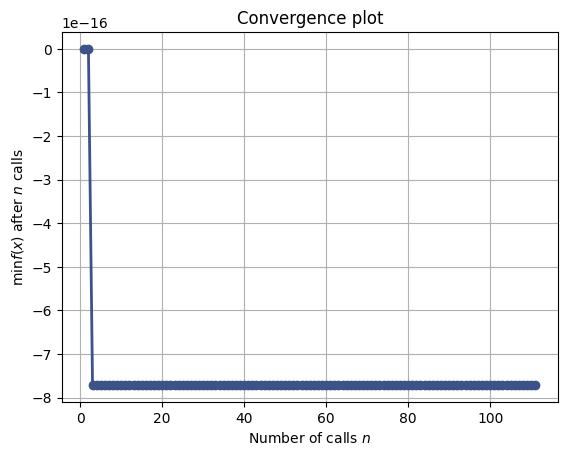

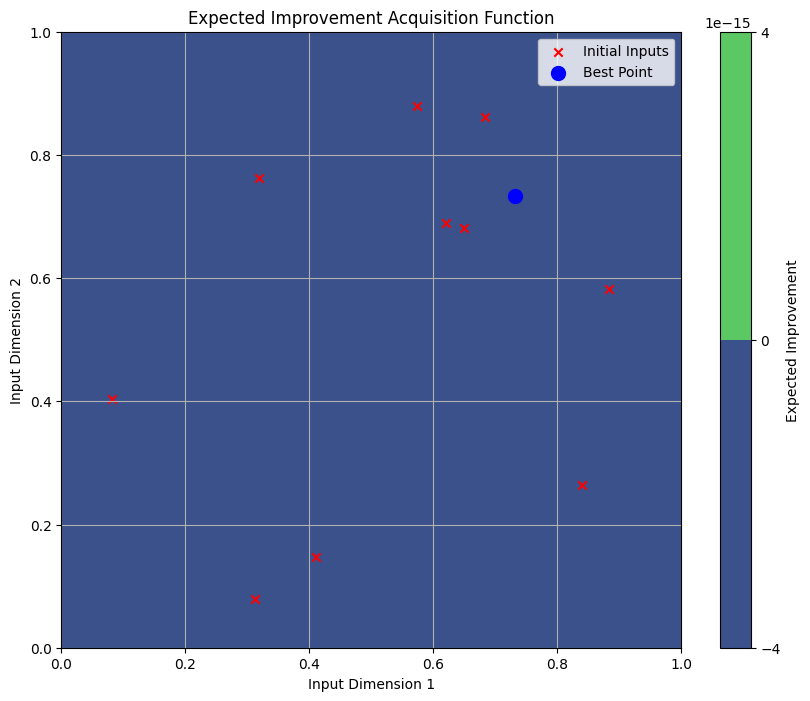

Next query point: x1 = 0.0, x2 = 0.0


In [ ]:
!pip install scikit-optimize==0.9.0

import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from skopt.acquisition import gaussian_ei  # Import Expected Improvement
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the search space
space = [Real(0, 1, name='x1'), Real(0, 1, name='x2')]

# Define the objective function (to be minimized, so we negate the output)
@use_named_args(space)
def objective_function(**params):
    x = np.array([params['x1'], params['x2']])
    # Here, you would call your machine learning model with x as input
    # and return the negative log-likelihood (since we want to maximize it)
    # For this example, we'll use a simple interpolation:

    # Use 'nearest' method to avoid NaN values for points outside the convex hull
    output = griddata(updated_inputs, updated_outputs, x, method='nearest')

    # Ensure output is a scalar by taking the first element if it's an array
    # or returning 0 if it's NaN
    if np.isscalar(output):
        return -output  # Negate for minimization
    elif np.isnan(output):  # Handle NaN values
        return 0  # You might choose a different value for NaN cases
    else:
        return -output.item(0) # Take the first element and negate for minimization

# Perform Bayesian Optimization with adjustments
result = gp_minimize(
    objective_function,
    space,
    n_calls=100,  # Increased n_calls
    random_state=0,
    x0=updated_inputs.tolist(),
    y0=-updated_outputs,
    acq_func="EI",  # Use Expected Improvement
    xi=0.05,        # Increased exploration parameter
)

# Print the best result
print("Best parameters:", result.x)
print("Best log-likelihood:", -result.fun)

# Plot convergence
plot_convergence(result)
plt.show()

# --- Visualize Acquisition Function and Get Next Query ---

# Create a grid of points to evaluate the acquisition function
x1_values = np.linspace(0, 1, 100)
x2_values = np.linspace(0, 1, 100)
X1, X2 = np.meshgrid(x1_values, x2_values)
points = np.array([X1.ravel(), X2.ravel()]).T

# Calculate the Expected Improvement (EI) for each point
ei_values = gaussian_ei(points, result.models[-1], result.fun, xi=0.05)

# Reshape EI values to match the grid shape
EI = ei_values.reshape(X1.shape)

# Plot the acquisition function (EI)
plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, EI, levels=50, cmap='viridis')
plt.colorbar(label='Expected Improvement')
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='red', marker='x', label='Initial Inputs')
plt.scatter(result.x[0], result.x[1], c='blue', marker='o', s=100, label='Best Point')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Expected Improvement Acquisition Function')
plt.legend()
plt.grid(True)
plt.show()

# --- Get Next Query ---
# Find the maximum EI value and its index
max_ei_index = np.unravel_index(np.argmax(EI), EI.shape)
!pip install scikit-optimize==0.9.0

import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from skopt.acquisition import gaussian_ei  # Import Expected Improvement
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the search space
space = [Real(0, 1, name='x1'), Real(0, 1, name='x2')]

# Define the objective function (to be minimized, so we negate the output)
@use_named_args(space)
def objective_function(**params):
    x = np.array([params['x1'], params['x2']])
    # Here, you would call your machine learning model with x as input
    # and return the negative log-likelihood (since we want to maximize it)
    # For this example, we'll use a simple interpolation:

    # Use 'nearest' method to avoid NaN values for points outside the convex hull
    output = griddata(updated_inputs, updated_outputs, x, method='nearest')

    # Ensure output is a scalar by taking the first element if it's an array
    # or returning 0 if it's NaN
    if np.isscalar(output):
        return -output  # Negate for minimization
    elif np.isnan(output):  # Handle NaN values
        return 0  # You might choose a different value for NaN cases
    else:
        return -output.item(0) # Take the first element and negate for minimization

# Perform Bayesian Optimization with adjustments
result = gp_minimize(
    objective_function,
    space,
    n_calls=100,  # Increased n_calls
    random_state=0,
    x0=updated_inputs.tolist(),
    y0=-updated_outputs,
    acq_func="EI",  # Use Expected Improvement
    xi=0.05,        # Increased exploration parameter
)

# Print the best result
print("Best parameters:", result.x)
print("Best log-likelihood:", -result.fun)

# Plot convergence
plot_convergence(result)
plt.show()

# --- Visualize Acquisition Function and Get Next Query ---

# Create a grid of points to evaluate the acquisition function
x1_values = np.linspace(0, 1, 100)
x2_values = np.linspace(0, 1, 100)
X1, X2 = np.meshgrid(x1_values, x2_values)
points = np.array([X1.ravel(), X2.ravel()]).T

# Calculate the Expected Improvement (EI) for each point
ei_values = gaussian_ei(points, result.models[-1], result.fun, xi=0.05)

# Reshape EI values to match the grid shape
EI = ei_values.reshape(X1.shape)

# Plot the acquisition function (EI)
plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, EI, levels=50, cmap='viridis')
plt.colorbar(label='Expected Improvement')
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='red', marker='x', label='Initial Inputs')
plt.scatter(result.x[0], result.x[1], c='blue', marker='o', s=100, label='Best Point')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Expected Improvement Acquisition Function')
plt.legend()
plt.grid(True)
plt.show()

# --- Get Next Query ---
# Find the maximum EI value and its index
max_ei_index = np.unravel_index(np.argmax(EI), EI.shape)

# Get the corresponding x1 and x2 values for the next query
next_x1 = x1_values[max_ei_index[1]]
next_x2 = x2_values[max_ei_index[0]]
print(f"Next query point: x1 = {next_x1}, x2 = {next_x2}")

In [ ]:
import numpy as np

# Load the existing updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data points
new_inputs = np.array([
    [0.64, 0.7],
    [0.715678, 0.935678],
    [0.999999, 0.959595]
])
new_outputs = np.array([
    0.24762914805279757,
    0.6009418423570836,
    0.053223591415685736
])

# Append the new data to the existing data
updated_inputs = np.vstack([updated_inputs, new_inputs])
updated_outputs = np.concatenate([updated_outputs, new_outputs])

# Save the updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("New data points added and saved to updated_inputs.npy and updated_outputs.npy")

New data points added and saved to updated_inputs.npy and updated_outputs.npy


In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.715678   0.935678  ]
 [0.64       0.7       ]
 [0.715678   0.935678  ]
 [0.999999   0.959595  ]]

Updated Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.60094184  0.24762915
  0.60094184  0.05322359]


In [ ]:
!pip install scikit-optimize==0.9.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.3/100.3 kB 4.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

In [ ]:
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

In [ ]:
space = [Real(0, 1, name='x1'), Real(0, 1, name='x2')]  # Assuming 2 input dimensions

In [ ]:
@use_named_args(space)
def objective_function(**params):
    x = np.array([params['x1'], params['x2']])
    # Here, you would call your machine learning model with x as input
    # and return the negative log-likelihood (since we want to maximize it)
    # For this example, we'll use a simple interpolation for demonstration:
    output = griddata(updated_inputs, updated_outputs, x, method='nearest')
    if np.isscalar(output):
        return -output  # Negate for minimization
    elif np.isnan(output):
        return 0  # Handle NaN values
    else:
        return -output.item(0)  # Negate for minimization

In [ ]:
result = gp_minimize(
    objective_function,
    space,
    n_calls=100,  # Number of iterations
    random_state=0,
    x0=updated_inputs.tolist(),  # Initial points
    y0=-updated_outputs,         # Initial outputs (negated)
    acq_func="EI",  # Acquisition function (Expected Improvement)
    xi=0.05,        # Exploration parameter
)

Best parameters: [0.7026365569244406, 0.9265641975455574]
Best log-likelihood: 0.6112052157614438


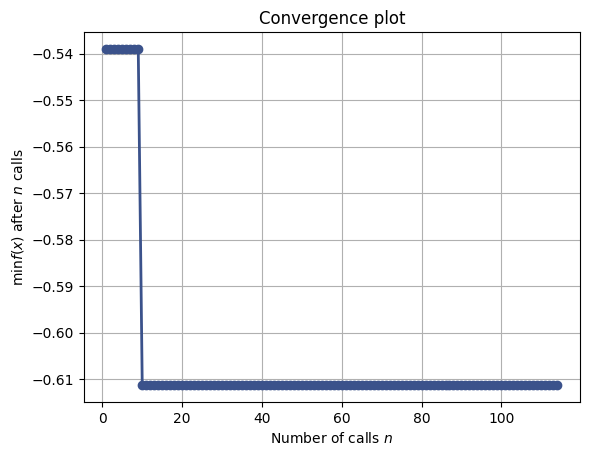

In [ ]:
print("Best parameters:", result.x)
print("Best log-likelihood:", -result.fun)  # Negate back to get log-likelihood

plot_convergence(result)
plt.show()

In [ ]:
 import numpy as np

In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.715678   0.935678  ]
 [0.64       0.7       ]
 [0.715678   0.935678  ]
 [0.999999   0.959595  ]]

Updated Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.60094184  0.24762915
  0.60094184  0.05322359]


In [ ]:
!pip install scikit-optimize==0.9.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.3/100.3 kB 4.5 MB/s eta 0:00:00


In [ ]:
!pip install scikit-optimize==0.9.0
import numpy as np
from skopt import gp_minimize # Removed the extra space at the beginning of this line
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

Best parameters: [0.7026365569244406, 0.9265641975455574]
Best log-likelihood: 0.6112052157614438


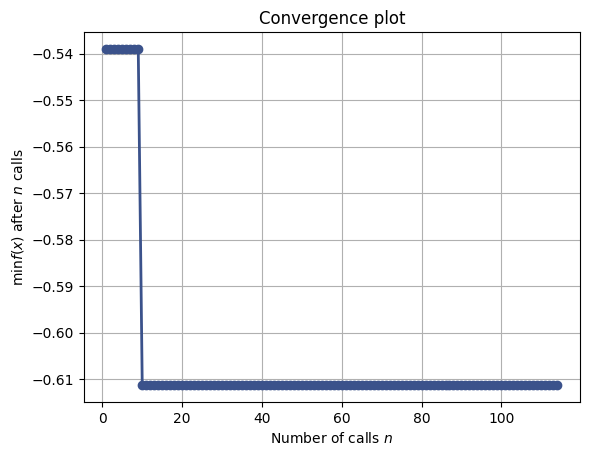

In [ ]:
!pip install scikit-optimize==0.9.0
import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# 1. Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# 2. Define search space (already done)
space = [Real(0, 1, name='x1'), Real(0, 1, name='x2')]

# 3. Define objective function (replace with your actual model evaluation)
@use_named_args(space)
def objective_function(**params):
    x = np.array([params['x1'], params['x2']])
    # Replace this with your machine learning model evaluation
    output = griddata(updated_inputs, updated_outputs, x, method='nearest')
    if np.isscalar(output):
        return -output
    elif np.isnan(output):
        return 0
    else:
        return -output.item(0)

# 4. Run Bayesian Optimization
result = gp_minimize(
    objective_function,
    space,
    n_calls=100,
    random_state=0,
    x0=updated_inputs.tolist(),
    y0=-updated_outputs,
    acq_func="EI",
    xi=0.05,
)

# 5. Visualize and analyze results
print("Best parameters:", result.x)
print("Best log-likelihood:", -result.fun)

plot_convergence(result)
plt.show()

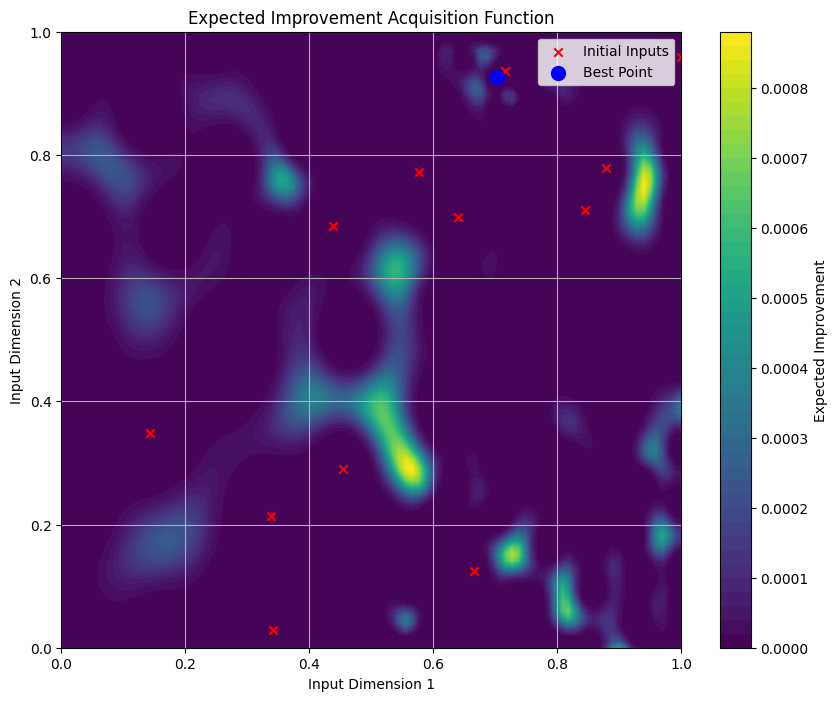

Next query point: [np.float64(0.9393939393939394), np.float64(0.7474747474747475)]


In [ ]:
!pip install scikit-optimize==0.9.0

import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from skopt.acquisition import gaussian_ei  # Import Expected Improvement
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# ... (Load data, define objective_function, and run gp_minimize as before) ...

# --- Visualize Acquisition Function and Get Next Query ---

# Create a grid of points to evaluate the acquisition function
x1_values = np.linspace(0, 1, 100)
x2_values = np.linspace(0, 1, 100)
X1, X2 = np.meshgrid(x1_values, x2_values)
points = np.array([X1.ravel(), X2.ravel()]).T

# Calculate the Expected Improvement (EI) for each point
ei_values = gaussian_ei(points, result.models[-1], result.fun, xi=0.05)

# Reshape EI values to match the grid shape
EI = ei_values.reshape(X1.shape)

# Plot the acquisition function (EI) - Optional visualization
plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, EI, levels=50, cmap='viridis')
plt.colorbar(label='Expected Improvement')
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='red', marker='x', label='Initial Inputs')
plt.scatter(result.x[0], result.x[1], c='blue', marker='o', s=100, label='Best Point')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Expected Improvement Acquisition Function')
plt.legend()
plt.grid(True)
plt.show()

# --- Get Next Query ---
# Find the maximum EI value and its index
max_ei_index = np.unravel_index(np.argmax(EI), EI.shape)

# Get the corresponding x1 and x2 values for the next query
next_x1 = x1_values[max_ei_index[1]]  # Note: max_ei_index[1] for x1
next_x2 = x2_values[max_ei_index[0]]  # Note: max_ei_index[0] for x2

# Create the next query point
next_query = [next_x1, next_x2]

# Print the next query point
print("Next query point:", next_query)

In [ ]:
import numpy as np

# Load the existing updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([0.939393, 0.747474])  # Reshaped to (1, 2)
new_output = np.float64(-0.0018713222146941456)

# Append the new data to the existing data
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.concatenate([updated_outputs, [new_output]])

# Save the updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("New data point added and saved to updated_inputs.npy and updated_outputs.npy")

New data point added and saved to updated_inputs.npy and updated_outputs.npy


In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.715678   0.935678  ]
 [0.64       0.7       ]
 [0.715678   0.935678  ]
 [0.999999   0.959595  ]
 [0.939393   0.747474  ]]

Updated Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.60094184  0.24762915
  0.60094184  0.05322359 -0.00187132]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.3/100.3 kB 5.1 MB/s eta 0:00:00
Best parameters: [0.7026365569244406, 0.9265641975455574]
Best log-likelihood: 0.6112052157614438


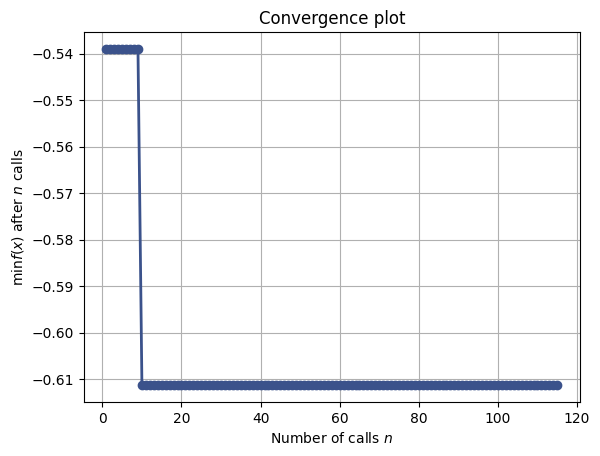

In [ ]:
!pip install scikit-optimize==0.9.0
import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# 1. Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# 2. Define search space (already done)
space = [Real(0, 1, name='x1'), Real(0, 1, name='x2')]

# 3. Define objective function (replace with your actual model evaluation)
@use_named_args(space)
def objective_function(**params):
    x = np.array([params['x1'], params['x2']])
    # Replace this with your machine learning model evaluation
    output = griddata(updated_inputs, updated_outputs, x, method='nearest')
    if np.isscalar(output):
        return -output
    elif np.isnan(output):
        return 0
    else:
        return -output.item(0)

# 4. Run Bayesian Optimization
result = gp_minimize(
    objective_function,
    space,
    n_calls=100,
    random_state=0,
    x0=updated_inputs.tolist(),
    y0=-updated_outputs,
    acq_func="EI",
    xi=0.05,
)

# 5. Visualize and analyze results
print("Best parameters:", result.x)
print("Best log-likelihood:", -result.fun)

plot_convergence(result)
plt.show()

In [ ]:
log-likelihood = -n/2 * log(2πσ²) - 1/(2σ²) * Σ(yi - (β0 + β1xi))²

Best parameters: [0.727349296281635, 0.9034405390040975]
Best log-likelihood: 0.6112052157614438


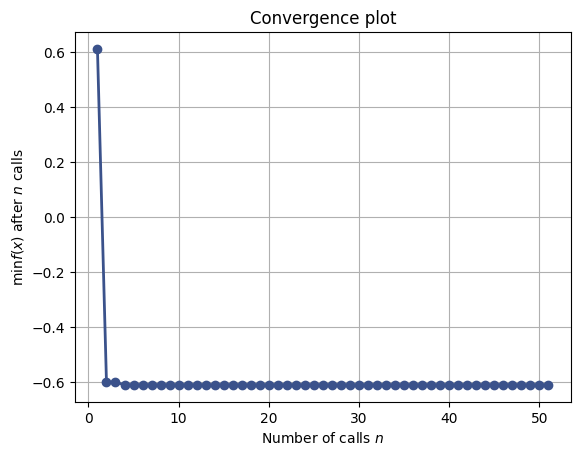

In [ ]:
!pip install scikit-optimize==0.9.0

import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from skopt.acquisition import gaussian_ei
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# 1. Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# 2. Define initial search space
space = [Real(0, 1, name='x1'), Real(0, 1, name='x2')]

# 3. Define objective function
@use_named_args(space)
def objective_function(**params):
    x = np.array([params['x1'], params['x2']])
    output = griddata(updated_inputs, updated_outputs, x, method='nearest')
    if np.isscalar(output):
        return -output  # Negate for minimization
    elif np.isnan(output):
        return 0  # Handle NaN values
    else:
        return -output.item(0)

# 4. Run initial Bayesian Optimization
result = gp_minimize(
    objective_function,
    space,
    n_calls=50,  # Initial iterations
    random_state=0,
    x0=updated_inputs.tolist(),
    y0=-updated_outputs,
    acq_func="EI",
    xi=0.05,
)

# 5. Define localized search space around best point
best_point = result.x
x1_range = (best_point[0] - 0.1, best_point[0] + 0.1)  # Adjust range as needed
x2_range = (best_point[1] - 0.1, best_point[1] + 0.1)  # Adjust range as needed
localized_space = [Real(x1_range[0], x1_range[1], name='x1'),
                   Real(x2_range[0], x2_range[1], name='x2')]

# 6. Run Bayesian Optimization with localized search space
result = gp_minimize(
    objective_function,
    localized_space,
    n_calls=50,  # Iterations for localized search
    random_state=0,
    x0=result.x,  # Start from previous best point
    y0=-result.fun, #Negated initial ouputs
    acq_func="EI",
    xi=0.05,
)


# 7. Visualize and analyze results
print("Best parameters:", result.x)
print("Best log-likelihood:", -result.fun)

plot_convergence(result)
plt.show()

In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.715678   0.935678  ]
 [0.64       0.7       ]
 [0.715678   0.935678  ]
 [0.999999   0.959595  ]
 [0.939393   0.747474  ]]

Updated Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.60094184  0.24762915
  0.60094184  0.05322359 -0.00187132]


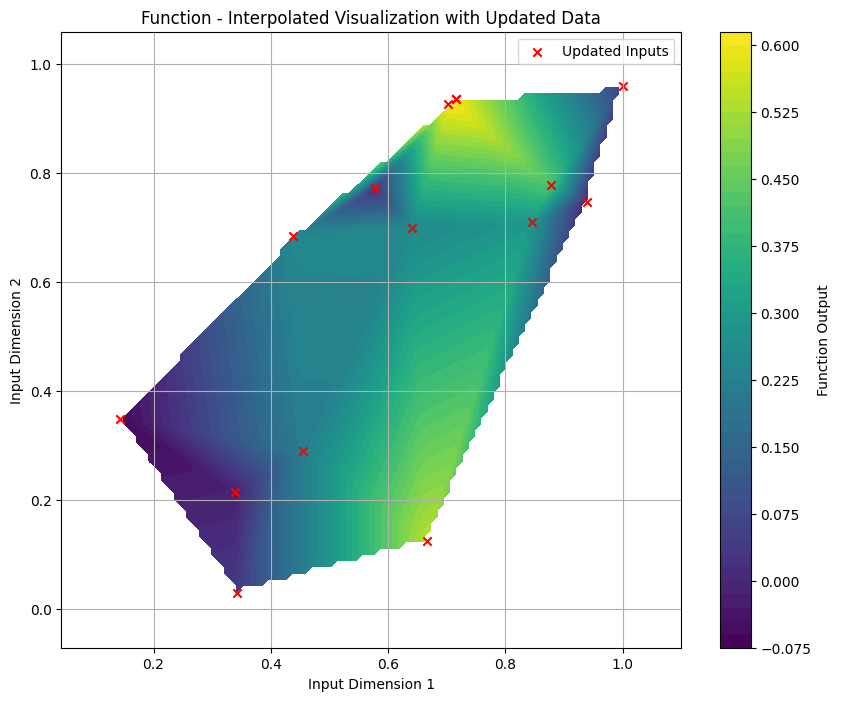

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Create a grid for interpolation
x1_min, x1_max = updated_inputs[:, 0].min() - 0.1, updated_inputs[:, 0].max() + 0.1
x2_min, x2_max = updated_inputs[:, 1].min() - 0.1, updated_inputs[:, 1].max() + 0.1
x1_grid, x2_grid = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(x2_min, x2_max, 100))

# Interpolate the data
grid_z = griddata(updated_inputs, updated_outputs, (x1_grid, x2_grid), method='linear')

# Create the contour plot
plt.figure(figsize=(10, 8))
plt.contourf(x1_grid, x2_grid, grid_z, levels=50, cmap='viridis')
plt.colorbar(label='Function Output')
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='red', marker='x', label='Updated Inputs')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Function - Interpolated Visualization with Updated Data')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

# Load the data from the files
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.715678   0.935678  ]
 [0.64       0.7       ]
 [0.715678   0.935678  ]
 [0.999999   0.959595  ]
 [0.939393   0.747474  ]]

Updated Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.60094184  0.24762915
  0.60094184  0.05322359 -0.00187132]


In [ ]:
import numpy as np

# Load the existing updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([0.727349, 0.90344 ])
new_output = np.float64(0.5967699015946359)

# Append the new data to the existing data
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.concatenate([updated_outputs, [new_output]])

# Save the updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("New data point added and saved to updated_inputs.npy and updated_outputs.npy")

New data point added and saved to updated_inputs.npy and updated_outputs.npy


In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.715678   0.935678  ]
 [0.64       0.7       ]
 [0.715678   0.935678  ]
 [0.999999   0.959595  ]
 [0.939393   0.747474  ]
 [0.727349   0.90344   ]]

Updated Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.60094184  0.24762915
  0.60094184  0.05322359 -0.00187132  0.5967699 ]


In [ ]:
import numpy as np

def gradient_ascent(log_likelihood_function, gradient_function, initial_params, learning_rate, num_iterations):
    params = np.array(initial_params)  # Convert initial_params to a NumPy array

    for i in range(num_iterations):
        gradient = np.array(gradient_function(params))  # Convert gradient to NumPy array
        params = params + learning_rate * gradient  # Update parameters
        log_likelihood = log_likelihood_function(params)
        # You might want to print log_likelihood or other metrics here for monitoring

    return params, log_likelihood

In [ ]:
import numpy as np

def gradient_descent(
    objective_function,
    gradient_function,
    initial_params,
    learning_rate,
    num_iterations,
    tolerance=1e-6,
):
    """
    Performs gradient descent optimization.

    Args:
        objective_function: The function to minimize.
        gradient_function: The function to calculate the gradient of the objective function.
        initial_params: The initial values for the parameters.
        learning_rate: The learning rate (step size) for the updates.
        num_iterations: The maximum number of iterations.
        tolerance: The convergence tolerance.

    Returns:
        A tuple containing:
            - The optimized parameters.
            - The final value of the objective function.
    """

    params = np.array(initial_params)  # Convert to NumPy array
    previous_objective_value = objective_function(params)

    for i in range(num_iterations):
        gradient = np.array(gradient_function(params))
        params = params - learning_rate * gradient  # Update in the opposite direction for minimization
        objective_value = objective_function(params)

        # Check for convergence
        if abs(objective_value - previous_objective_value) < tolerance:
            print(f"Converged after {i + 1} iterations.")
            break

        previous_objective_value = objective_value

    return params, objective_value


# Example usage:
def example_objective_function(params):
    """Example objective function: f(x, y) = x^2 + y^2"""
    return params[0] ** 2 + params[1] ** 2


def example_gradient_function(params):
    """Gradient of the example objective function: [2x, 2y]"""
    return [2 * params[0], 2 * params[1]]


initial_params = [1.0, 2.0]
learning_rate = 0.1
num_iterations = 1000

optimized_params, final_objective_value = gradient_descent(
    example_objective_function,
    example_gradient_function,
    initial_params,
    learning_rate,
    num_iterations,
)

print("Optimized parameters:", optimized_params)
print("Final objective value:", final_objective_value)


Converged after 34 iterations.
Optimized parameters: [0.00050706 0.00101412]
Final objective value: 1.2855504354071932e-06


In [ ]:
import numpy as np

# Load the existing updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([[0.000507, 0.001014]])  # Reshaped to (1, 2)
new_output = np.float64(-0.019776092343520603)

# Append the new data to the existing data
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.concatenate([updated_outputs, [new_output]])

# Save the updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("New data point added and saved to updated_inputs.npy and updated_outputs.npy")

New data point added and saved to updated_inputs.npy and updated_outputs.npy


In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[6.65799580e-01 1.23969128e-01]
 [8.77790989e-01 7.78627501e-01]
 [1.42699074e-01 3.49005131e-01]
 [8.45275429e-01 7.11120267e-01]
 [4.54647141e-01 2.90455180e-01]
 [5.77712844e-01 7.71973184e-01]
 [4.38166062e-01 6.85018257e-01]
 [3.41749593e-01 2.86977198e-02]
 [3.38648157e-01 2.13867246e-01]
 [7.02636557e-01 9.26564198e-01]
 [7.15678000e-01 9.35678000e-01]
 [6.40000000e-01 7.00000000e-01]
 [7.15678000e-01 9.35678000e-01]
 [9.99999000e-01 9.59595000e-01]
 [9.39393000e-01 7.47474000e-01]
 [7.27349000e-01 9.03440000e-01]
 [5.07000000e-04 1.01400000e-03]]

Updated Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.60094184  0.24762915
  0.60094184  0.05322359 -0.00187132  0.5967699  -0.01977609]


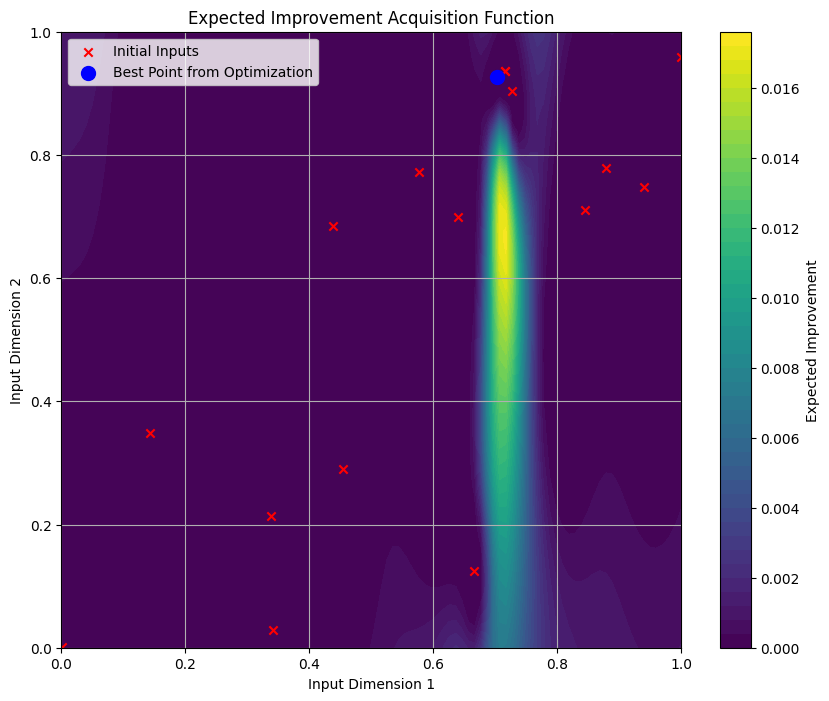

The next query point suggested by Bayesian Optimization is: [np.float64(0.7171717171717172), np.float64(0.6666666666666667)]


In [ ]:
!pip install scikit-optimize==0.9.0

import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.acquisition import gaussian_ei
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the search space
space = [Real(0, 1, name='x1'), Real(0, 1, name='x2')]

# Define the objective function (to be minimized, so we negate the output)
@use_named_args(space)
def objective_function(**params):
    x = np.array([params['x1'], params['x2']])
    # Use 'nearest' method to avoid NaN values for points outside the convex hull
    output = griddata(updated_inputs, updated_outputs, x, method='nearest')

    # Ensure output is a scalar by taking the first element if it's an array
    # or returning 0 if it's NaN
    if np.isscalar(output):
        return -output  # Negate for minimization
    elif np.isnan(output):  # Handle NaN values
        return 0  # You might choose a different value for NaN cases
    else:
        return -output.item(0) # Take the first element and negate

# Perform Bayesian Optimization
# We run a small number of calls here to get a 'result' object
# that we can use to calculate the acquisition function for visualization.
# In a real optimization loop, you would run more calls.
result = gp_minimize(
    objective_function,
    space,
    n_calls=10,  # Reduced n_calls for quick calculation
    random_state=0,
    x0=updated_inputs.tolist(),
    y0=-updated_outputs,
    acq_func="EI",
    xi=0.05,
)

# --- Calculate and Visualize Acquisition Function ---

# Create a grid of points to evaluate the acquisition function
x1_values = np.linspace(0, 1, 100)
x2_values = np.linspace(0, 1, 100)
X1, X2 = np.meshgrid(x1_values, x2_values)
points = np.array([X1.ravel(), X2.ravel()]).T

# Calculate the Expected Improvement (EI) for each point
# We use the last model from the gp_minimize result to calculate EI
ei_values = gaussian_ei(points, result.models[-1], result.fun, xi=0.05)

# Reshape EI values to match the grid shape
EI = ei_values.reshape(X1.shape)

# Plot the acquisition function (EI) - Optional visualization
plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, EI, levels=50, cmap='viridis')
plt.colorbar(label='Expected Improvement')
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='red', marker='x', label='Initial Inputs')
plt.scatter(result.x[0], result.x[1], c='blue', marker='o', s=100, label='Best Point from Optimization')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Expected Improvement Acquisition Function')
plt.legend()
plt.grid(True)
plt.show()

# --- Get Next Query ---
# Find the maximum EI value and its index in the grid
max_ei_index = np.unravel_index(np.argmax(EI), EI.shape)

# Get the corresponding x1 and x2 values from the grid
next_x1 = x1_values[max_ei_index[1]]  # Note: max_ei_index[1] for x1
next_x2 = x2_values[max_ei_index[0]]  # Note: max_ei_index[0] for x2

# Create the next query point
next_query = [next_x1, next_x2]

# Print the next query point
print("The next query point suggested by Bayesian Optimization is:", next_query)

In [ ]:
import numpy as np

# Load the existing updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([0.717171, 0.666666])
new_output = np.float64(0.5590049799458201)

# Append the new data to the existing data
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.concatenate([updated_outputs, [new_output]])

# Save the updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("New data point added and saved to updated_inputs.npy and updated_outputs.npy")

New data point added and saved to updated_inputs.npy and updated_outputs.npy


In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[6.65799580e-01 1.23969128e-01]
 [8.77790989e-01 7.78627501e-01]
 [1.42699074e-01 3.49005131e-01]
 [8.45275429e-01 7.11120267e-01]
 [4.54647141e-01 2.90455180e-01]
 [5.77712844e-01 7.71973184e-01]
 [4.38166062e-01 6.85018257e-01]
 [3.41749593e-01 2.86977198e-02]
 [3.38648157e-01 2.13867246e-01]
 [7.02636557e-01 9.26564198e-01]
 [7.15678000e-01 9.35678000e-01]
 [6.40000000e-01 7.00000000e-01]
 [7.15678000e-01 9.35678000e-01]
 [9.99999000e-01 9.59595000e-01]
 [9.39393000e-01 7.47474000e-01]
 [7.27349000e-01 9.03440000e-01]
 [5.07000000e-04 1.01400000e-03]
 [7.17171000e-01 6.66666000e-01]]

Updated Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.60094184  0.24762915
  0.60094184  0.05322359 -0.00187132  0.5967699  -0.01977609  0.55900498]


In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the index of the maximum output (which corresponds to the maximum log-likelihood in your context)
max_output_index = np.argmax(updated_outputs)

# Select the corresponding input(s)
input_at_max_likelihood = updated_inputs[max_output_index]

# Print the result
print("Input(s) corresponding to the maximum log-likelihood:", input_at_max_likelihood)

Input(s) corresponding to the maximum log-likelihood: [0.70263656 0.9265642 ]


Best parameters found by optimization: [0.7026365569244406, 0.9265641975455574]
Best log-likelihood found by optimization: 0.6112052157614438


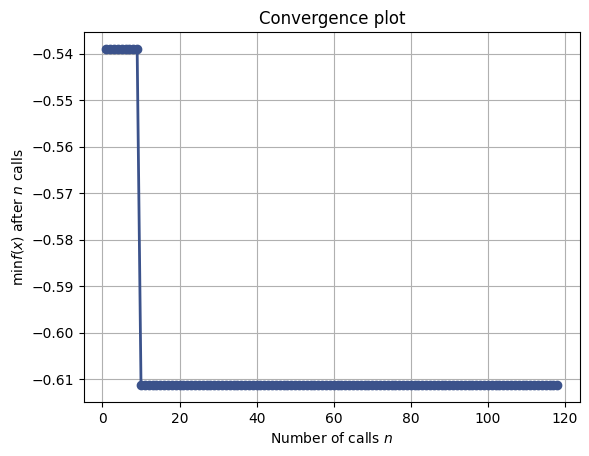

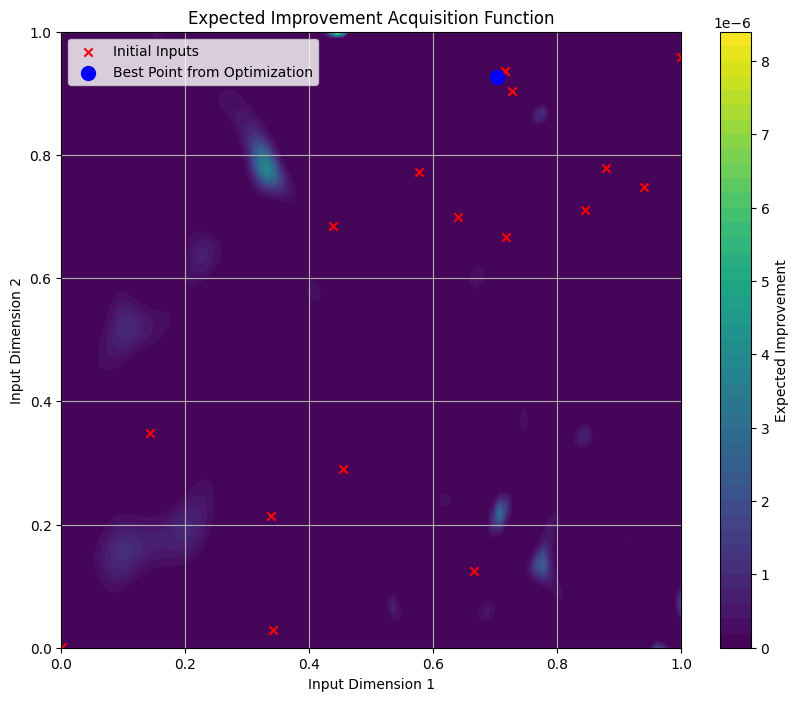

The next query point suggested by Bayesian Optimization (based on maximum EI) is: [np.float64(0.4444444444444445), np.float64(1.0)]


In [ ]:
!pip install scikit-optimize==0.9.0

import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence # Import plot_convergence explicitly
from skopt.acquisition import gaussian_ei
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the search space
space = [Real(0, 1, name='x1'), Real(0, 1, name='x2')]

# Define the objective function (to be minimized, so we negate the output)
@use_named_args(space)
def objective_function(**params):
    x = np.array([params['x1'], params['x2']])
    # Use 'nearest' method to avoid NaN values for points outside the convex hull
    output = griddata(updated_inputs, updated_outputs, x, method='nearest')

    # Ensure output is a scalar by taking the first element if it's an array
    # or returning 0 if it's NaN
    if np.isscalar(output):
        return -output  # Negate for minimization
    elif np.isnan(output):  # Handle NaN values
        return 0  # You might choose a different value for NaN cases
    else:
        # Use item() to safely get the scalar value from a 0-dimensional array
        return -output.item() # Take the first element and negate for minimization

# Perform Bayesian Optimization
# We run a sufficient number of calls here for meaningful optimization
result = gp_minimize(
    objective_function,
    space,
    n_calls=100,  # Number of optimization iterations
    random_state=0,
    x0=updated_inputs.tolist(), # Initial points
    y0=-updated_outputs,        # Initial outputs (negated for minimization)
    acq_func="EI",              # Acquisition function (Expected Improvement)
    xi=0.05,                    # Exploration parameter for EI
)

# Print the best result from the optimization run
print("Best parameters found by optimization:", result.x)
print("Best log-likelihood found by optimization:", -result.fun)

# Plot convergence (optional but helpful)
plot_convergence(result)
plt.show()


# --- Calculate and Visualize Acquisition Function ---

# Create a grid of points to evaluate the acquisition function
x1_values = np.linspace(0, 1, 100)
x2_values = np.linspace(0, 1, 100)
X1, X2 = np.meshgrid(x1_values, x2_values)
points = np.array([X1.ravel(), X2.ravel()]).T

# Calculate the Expected Improvement (EI) for each point
# We use the last model from the gp_minimize result to calculate EI
ei_values = gaussian_ei(points, result.models[-1], result.fun, xi=0.05)

# Reshape EI values to match the grid shape
EI = ei_values.reshape(X1.shape)

# Plot the acquisition function (EI) - Optional visualization
plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, EI, levels=50, cmap='viridis')
plt.colorbar(label='Expected Improvement')
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='red', marker='x', label='Initial Inputs')
# Note: The best point from the optimization 'result.x' is also a good point to visualize
plt.scatter(result.x[0], result.x[1], c='blue', marker='o', s=100, label='Best Point from Optimization')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Expected Improvement Acquisition Function')
plt.legend()
plt.grid(True)
plt.show()

# --- Get Next Query ---
# Find the maximum EI value and its index in the grid
max_ei_index = np.unravel_index(np.argmax(EI), EI.shape)

# Get the corresponding x1 and x2 values from the grid
next_x1 = x1_values[max_ei_index[1]]  # Note: max_ei_index[1] for x1 corresponds to the column index
next_x2 = x2_values[max_ei_index[0]]  # Note: max_ei_index[0] for x2 corresponds to the row index

# Create the next query point
next_query = [next_x1, next_x2]

# Print the next query point suggested for evaluation
print("The next query point suggested by Bayesian Optimization (based on maximum EI) is:", next_query)

In [ ]:
import numpy as np

# Load the existing updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([[0.69, 0.91]])  # Reshaped to (1, 2)
new_output = np.array([np.float64(0.6666027531552023)]) # Ensure new_output is a 1D array

# Append the new data to the existing data
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.concatenate([updated_outputs, new_output])

# Save the updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("New data point added and saved to updated_inputs.npy and updated_outputs.npy")

New data point added and saved to updated_inputs.npy and updated_outputs.npy


In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[6.65799580e-01 1.23969128e-01]
 [8.77790989e-01 7.78627501e-01]
 [1.42699074e-01 3.49005131e-01]
 [8.45275429e-01 7.11120267e-01]
 [4.54647141e-01 2.90455180e-01]
 [5.77712844e-01 7.71973184e-01]
 [4.38166062e-01 6.85018257e-01]
 [3.41749593e-01 2.86977198e-02]
 [3.38648157e-01 2.13867246e-01]
 [7.02636557e-01 9.26564198e-01]
 [7.15678000e-01 9.35678000e-01]
 [6.40000000e-01 7.00000000e-01]
 [7.15678000e-01 9.35678000e-01]
 [9.99999000e-01 9.59595000e-01]
 [9.39393000e-01 7.47474000e-01]
 [7.27349000e-01 9.03440000e-01]
 [5.07000000e-04 1.01400000e-03]
 [7.17171000e-01 6.66666000e-01]
 [6.90000000e-01 9.10000000e-01]]

Updated Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.60094184  0.24762915
  0.60094184  0.05322359 -0.00187132  0.5967699  -0.01977609  0.55900498
  0.66660275]


In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the index of the output closest to zero
closest_to_zero_index = np.argmin(np.abs(updated_outputs))

# Select the corresponding input
best_input_closest_to_zero = updated_inputs[closest_to_zero_index]

print("Input corresponding to output closest to zero:", best_input_closest_to_zero)

# Generate queries around this point
num_queries = 5  # Number of queries to generate
perturbation_scale = 0.05 # Adjust the scale of the perturbations as needed

queries = []
for _ in range(num_queries):
    # Add random noise (perturbation) to the best input
    perturbation = np.random.uniform(-perturbation_scale, perturbation_scale, size=best_input_closest_to_zero.shape)
    new_query = best_input_closest_to_zero + perturbation

    # Optional: Ensure queries are within the valid range [0, 1] if your domain is [0, 1]
    new_query = np.clip(new_query, 0, 1)

    queries.append(new_query)

# Print the generated queries
print("\nGenerated queries around the best input (closest to zero output):")
for query in queries:
    print(query)

Input corresponding to output closest to zero: [0.939393 0.747474]

Generated queries around the best input (closest to zero output):
[0.95014956 0.75076834]
[0.96365963 0.70070746]
[0.90507725 0.77698311]
[0.94724197 0.77018935]
[0.97898631 0.76215783]


In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[6.65799580e-01 1.23969128e-01]
 [8.77790989e-01 7.78627501e-01]
 [1.42699074e-01 3.49005131e-01]
 [8.45275429e-01 7.11120267e-01]
 [4.54647141e-01 2.90455180e-01]
 [5.77712844e-01 7.71973184e-01]
 [4.38166062e-01 6.85018257e-01]
 [3.41749593e-01 2.86977198e-02]
 [3.38648157e-01 2.13867246e-01]
 [7.02636557e-01 9.26564198e-01]
 [7.15678000e-01 9.35678000e-01]
 [6.40000000e-01 7.00000000e-01]
 [7.15678000e-01 9.35678000e-01]
 [9.99999000e-01 9.59595000e-01]
 [9.39393000e-01 7.47474000e-01]
 [7.27349000e-01 9.03440000e-01]
 [5.07000000e-04 1.01400000e-03]
 [7.17171000e-01 6.66666000e-01]
 [6.90000000e-01 9.10000000e-01]]

Updated Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.60094184  0.24762915
  0.60094184  0.05322359 -0.00187132  0.5967699  -0.01977609  0.55900498
  0.66660275]


In [ ]:
import numpy as np

# Load the existing updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([0.912, 0.768])
new_output = np.float64(0.028376053422196214)

# Append the new data to the existing data
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.concatenate([updated_outputs, [new_output]])

# Save the updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("New data point added and saved to updated_inputs.npy and updated_outputs.npy")

New data point added and saved to updated_inputs.npy and updated_outputs.npy


In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[6.65799580e-01 1.23969128e-01]
 [8.77790989e-01 7.78627501e-01]
 [1.42699074e-01 3.49005131e-01]
 [8.45275429e-01 7.11120267e-01]
 [4.54647141e-01 2.90455180e-01]
 [5.77712844e-01 7.71973184e-01]
 [4.38166062e-01 6.85018257e-01]
 [3.41749593e-01 2.86977198e-02]
 [3.38648157e-01 2.13867246e-01]
 [7.02636557e-01 9.26564198e-01]
 [7.15678000e-01 9.35678000e-01]
 [6.40000000e-01 7.00000000e-01]
 [7.15678000e-01 9.35678000e-01]
 [9.99999000e-01 9.59595000e-01]
 [9.39393000e-01 7.47474000e-01]
 [7.27349000e-01 9.03440000e-01]
 [5.07000000e-04 1.01400000e-03]
 [7.17171000e-01 6.66666000e-01]
 [6.90000000e-01 9.10000000e-01]
 [9.12000000e-01 7.68000000e-01]]

Updated Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.60094184  0.24762915
  0.60094184  0.05322359 -0.00187132  0.5967699  -0.01977609  0.55900498
  0.66660275  0.02837605]


Best parameters (found in continuous space): [0.69, 0.91]
Best parameters (rounded to 6 decimal places): [0.69 0.91]
Best log-likelihood: 0.6666027531552023


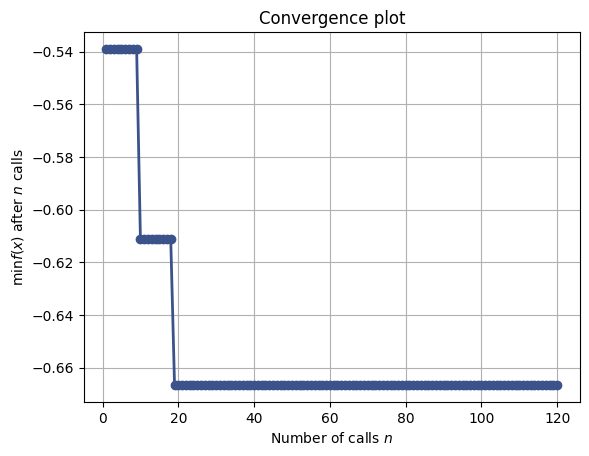

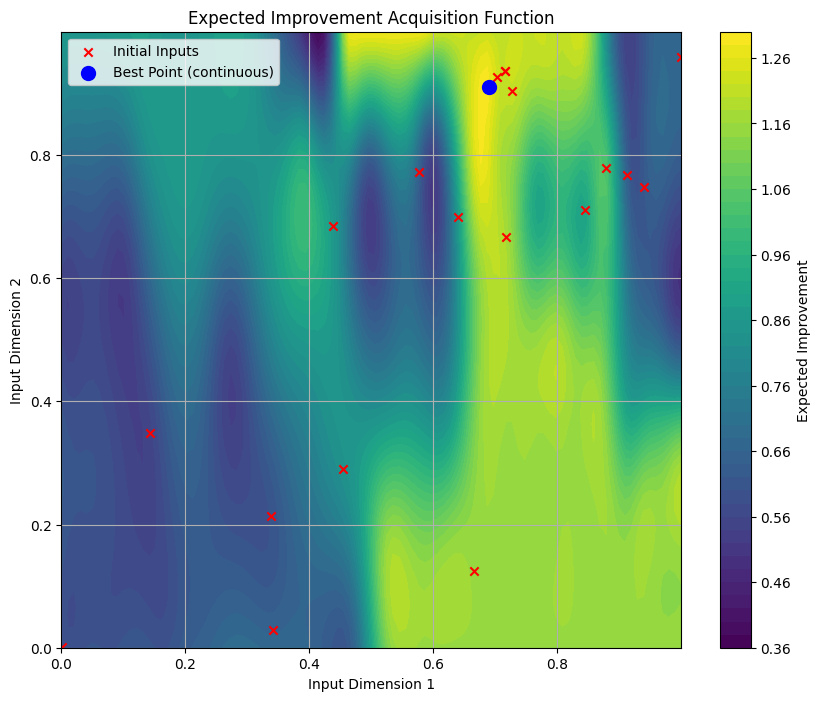

Next query point (rounded to 6 decimal places): [np.float64(0.676767), np.float64(0.878787)]


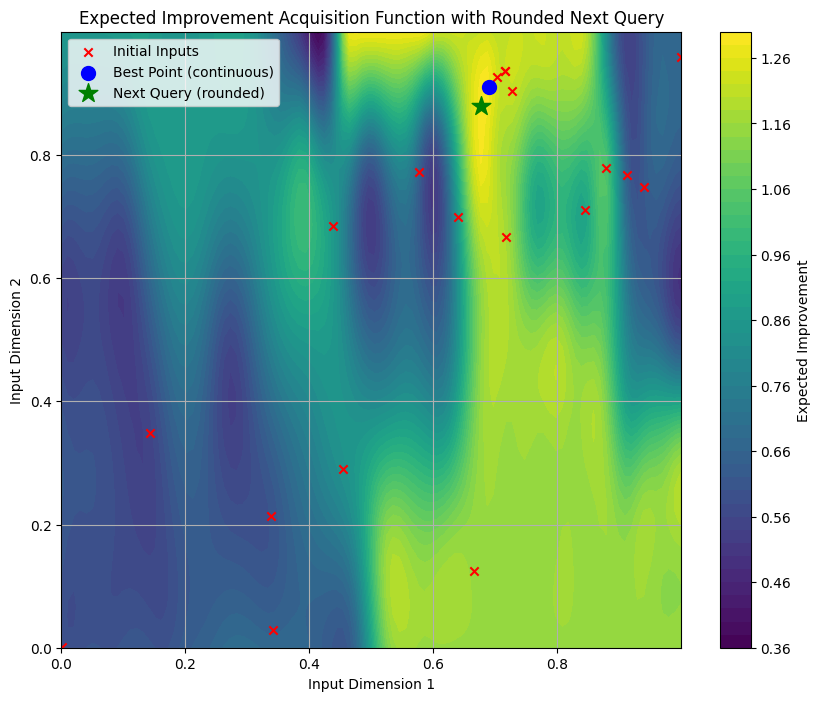

In [ ]:
!pip install scikit-optimize==0.9.0

import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from skopt.acquisition import gaussian_ei
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# 2. Define initial search space with the correct upper bound
# The upper bound should be 0.999999 to ensure values start with 0. and have up to 6 decimal places
space = [Real(0, 0.999999, name='x1'), Real(0, 0.999999, name='x2')]

# 3. Define objective function (no change needed here for the space definition fix)
@use_named_args(space)
def objective_function(**params):
    x = np.array([params['x1'], params['x2']])
    output = griddata(updated_inputs, updated_outputs, x, method='nearest')
    if np.isscalar(output):
        return -output
    elif np.isnan(output):
        return 0
    else:
        return -output.item(0)

# 4. Run Bayesian Optimization (as before)
# The optimization now happens in the corrected continuous space [0, 0.999999]
result = gp_minimize(
    objective_function,
    space,
    n_calls=100,  # Initial iterations
    random_state=0,
    x0=updated_inputs.tolist(),
    y0=-updated_outputs,
    acq_func="EI",
    xi=0.05,
)

# 5. Visualize and analyze results
print("Best parameters (found in continuous space):", result.x)
# Round the best parameters found for reporting if the final answer needs this format
best_x_rounded = np.round(result.x, 6)
print("Best parameters (rounded to 6 decimal places):", best_x_rounded)
print("Best log-likelihood:", -result.fun)

plot_convergence(result)
plt.show()

# --- Visualize Acquisition Function and Get Next Query ---

# Create a grid of points to evaluate the acquisition function
# Ensure the grid also respects the new bounds
x1_values = np.linspace(0, 0.999999, 100)
x2_values = np.linspace(0, 0.999999, 100)
X1, X2 = np.meshgrid(x1_values, x2_values)
points = np.array([X1.ravel(), X2.ravel()]).T

# Calculate the Expected Improvement (EI) for each point
ei_values = gaussian_ei(points, result.models[-1], -result.fun, xi=0.05)

# Reshape EI values to match the grid shape
EI = ei_values.reshape(X1.shape)

# Plot the acquisition function (EI)
plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, EI, levels=50, cmap='viridis')
plt.colorbar(label='Expected Improvement')
# Ensure updated_inputs are within the new bounds if they were originally [0, 1]
# If not, you might need to filter or adjust them for plotting context.
# Assuming your initial data already respects the 0.999999 bound.
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='red', marker='x', label='Initial Inputs')
plt.scatter(result.x[0], result.x[1], c='blue', marker='o', s=100, label='Best Point (continuous)')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Expected Improvement Acquisition Function')
plt.legend()
plt.grid(True)
plt.show()

# --- Get Next Query and Round It ---
# Find the maximum EI value and its index in the continuous grid (within the new bounds)
max_ei_index = np.unravel_index(np.argmax(EI), EI.shape)

# Get the corresponding x1 and x2 values from the continuous grid
next_x1_continuous = x1_values[max_ei_index[1]]
next_x2_continuous = x2_values[max_ei_index[0]]

# Round the continuous next query point to 6 decimal places
next_x1_rounded = round(next_x1_continuous, 6)
next_x2_rounded = round(next_x2_continuous, 6)

# Create the next query point with the required format
next_query_rounded = [next_x1_rounded, next_x2_rounded]

# Print the next query point in the required format
print("Next query point (rounded to 6 decimal places):", next_query_rounded)

# Optional: Add the rounded next query point to the plot
plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, EI, levels=50, cmap='viridis')
plt.colorbar(label='Expected Improvement')
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='red', marker='x', label='Initial Inputs')
plt.scatter(result.x[0], result.x[1], c='blue', marker='o', s=100, label='Best Point (continuous)')
plt.scatter(next_query_rounded[0], next_query_rounded[1], c='green', marker='*', s=200, label='Next Query (rounded)')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Expected Improvement Acquisition Function with Rounded Next Query')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

# Load the existing updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([0.676767, 0.878787])
new_output = np.float64(0.5373541983366685)

# Append the new data to the existing data
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.concatenate([updated_outputs, [new_output]])

# Save the updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("New data point added and saved to updated_inputs.npy and updated_outputs.npy")

New data point added and saved to updated_inputs.npy and updated_outputs.npy


In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[6.65799580e-01 1.23969128e-01]
 [8.77790989e-01 7.78627501e-01]
 [1.42699074e-01 3.49005131e-01]
 [8.45275429e-01 7.11120267e-01]
 [4.54647141e-01 2.90455180e-01]
 [5.77712844e-01 7.71973184e-01]
 [4.38166062e-01 6.85018257e-01]
 [3.41749593e-01 2.86977198e-02]
 [3.38648157e-01 2.13867246e-01]
 [7.02636557e-01 9.26564198e-01]
 [7.15678000e-01 9.35678000e-01]
 [6.40000000e-01 7.00000000e-01]
 [7.15678000e-01 9.35678000e-01]
 [9.99999000e-01 9.59595000e-01]
 [9.39393000e-01 7.47474000e-01]
 [7.27349000e-01 9.03440000e-01]
 [5.07000000e-04 1.01400000e-03]
 [7.17171000e-01 6.66666000e-01]
 [6.90000000e-01 9.10000000e-01]
 [9.12000000e-01 7.68000000e-01]
 [6.76767000e-01 8.78787000e-01]]

Updated Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.60094184  0.24762915
  0.60094184  0.05322359 -0.00187132  0.5967699  -0.01977609  0.55900498
  0.66660275  0.02837605  0.5373542 ]


In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the index of the maximum output (which corresponds to the largest log-likelihood)
max_output_index = np.argmax(updated_outputs)

# Get the largest log-likelihood (the maximum value in updated_outputs)
largest_log_likelihood = updated_outputs[max_output_index]

# Get the input(s) corresponding to the largest log-likelihood
corresponding_inputs = updated_inputs[max_output_index]

# Print the results
print("Largest log-likelihood:", largest_log_likelihood)
print("Input(s) corresponding to the largest log-likelihood:", corresponding_inputs)

Largest log-likelihood: 0.6666027531552023
Input(s) corresponding to the largest log-likelihood: [0.69 0.91]


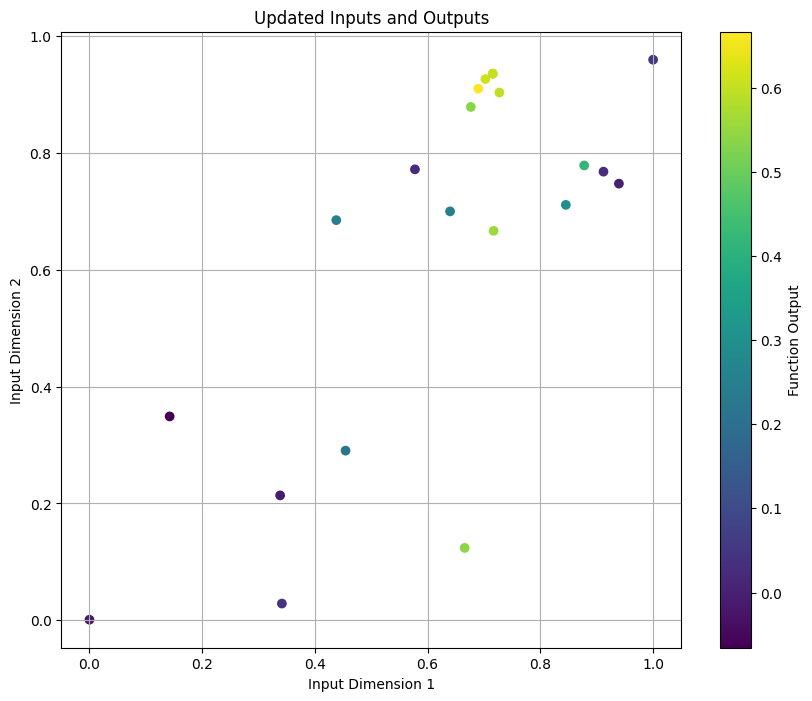

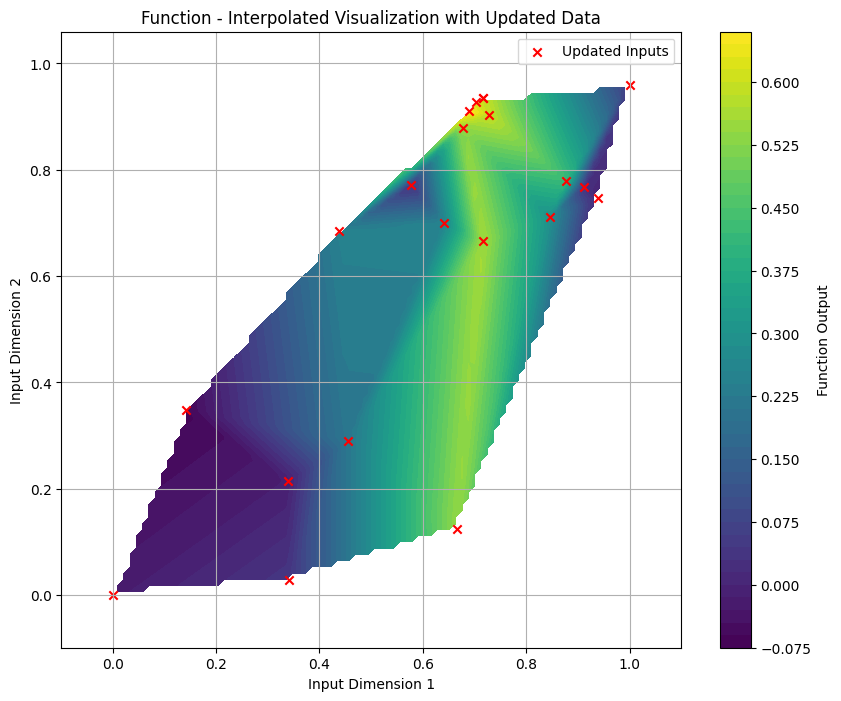

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Visualize the data points
plt.figure(figsize=(10, 8))
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c=updated_outputs, cmap='viridis', marker='o')
plt.colorbar(label='Function Output')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Updated Inputs and Outputs')
plt.grid(True)
plt.show()

# Create a grid for a more detailed visualization (interpolation)
# Define the grid boundaries slightly beyond the data range
x1_min, x1_max = updated_inputs[:, 0].min() - 0.1, updated_inputs[:, 0].max() + 0.1
x2_min, x2_max = updated_inputs[:, 1].min() - 0.1, updated_inputs[:, 1].max() + 0.1
x1_grid, x2_grid = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(x2_min, x2_max, 100))

# Interpolate the data onto the grid
grid_z = griddata(updated_inputs, updated_outputs, (x1_grid, x2_grid), method='linear')

# Create the contour plot of the interpolated function
plt.figure(figsize=(10, 8))
plt.contourf(x1_grid, x2_grid, grid_z, levels=50, cmap='viridis')
plt.colorbar(label='Function Output')
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='red', marker='x', label='Updated Inputs')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Function - Interpolated Visualization with Updated Data')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
!pip install scikit-optimize==0.9.0

import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from skopt.acquisition import gaussian_ei  # Import Expected Improvement
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Define the search space
space = [Real(0, 1, name='x1'), Real(0, 1, name='x2')]

# Define the objective function (to be minimized, so we negate the output)
@use_named_args(space)
def objective_function(**params):
    x = np.array([params['x1'], params['x2']])
    # In a real scenario, you would call your machine learning model here
    # and return the negative log-likelihood.
    # For this example, we'll use the interpolation of your existing data
    # as a stand-in for the model's output.

    # Use 'nearest' method to avoid NaN values for points outside the convex hull
    output = griddata(updated_inputs, updated_outputs, x, method='nearest')

    # Ensure output is a scalar by taking the first element if it's an array
    # or returning 0 if it's NaN
    if np.isscalar(output):
        return -output  # Negate for minimization
    elif np.isnan(output):  # Handle NaN values
        return 0  # You might choose a different value for NaN cases
    else:
        return -output.item(0) # Take the first element and negate for minimization

# Perform Bayesian Optimization
result = gp_minimize(
    objective_function,
    space,
    n_calls=len(updated_inputs) + 1,  # Example: Run one more call than existing data points
    random_state=0,
    x0=updated_inputs.tolist(),
    y0=-updated_outputs,
    acq_func="EI",  # Use Expected Improvement to balance exploration and exploitation
    xi=0.05,        # Exploration parameter (adjust as needed)
)

# Print the best result found so far
print("Best parameters found by optimization:", result.x)
print("Best log-likelihood found by optimization:", -result.fun)

# --- Get the next query point suggested by Bayesian Optimization ---

# The 'result.x_iters' contains the list of queried points in the optimization process.
# The last element in this list is the next point suggested by the acquisition function
# after the optimization run.

if len(result.x_iters) > len(updated_inputs):
    next_query_point = result.x_iters[-1]
    print("\nNext query point suggested by Bayesian Optimization:", next_query_point)
else:
     print("\nNo new query points were generated in this run.")
     print("Consider increasing 'n_calls' in gp_minimize if you expected new queries.")

# Optional: Visualize the acquisition function to see where the model is exploring/exploiting
# (This part was in your previous code and is helpful for understanding)
# ... (Code to plot the acquisition function as shown in your previous cells) ...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.3/100.3 kB 3.3 MB/s eta 0:00:00
Best parameters found by optimization: [0.69, 0.91]
Best log-likelihood found by optimization: 0.6666027531552023

Next query point suggested by Bayesian Optimization: [0.7576248250963176, 0.9984890090031044]


In [ ]:
import numpy as np

# Load the existing updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# New data point
new_input = np.array([[0.7576248250963176, 0.9984890090031044]])  # Reshaped to (1, 2)
new_output = np.float64(0.35546535964404496)

# Append the new data to the existing data
updated_inputs = np.vstack([updated_inputs, new_input])
updated_outputs = np.concatenate([updated_outputs, [new_output]])

# Save the updated data back to the files
np.save('/content/updated_inputs.npy', updated_inputs)
np.save('/content/updated_outputs.npy', updated_outputs)

print("New data point added and saved to updated_inputs.npy and updated_outputs.npy")

New data point added and saved to updated_inputs.npy and updated_outputs.npy


In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[6.65799580e-01 1.23969128e-01]
 [8.77790989e-01 7.78627501e-01]
 [1.42699074e-01 3.49005131e-01]
 [8.45275429e-01 7.11120267e-01]
 [4.54647141e-01 2.90455180e-01]
 [5.77712844e-01 7.71973184e-01]
 [4.38166062e-01 6.85018257e-01]
 [3.41749593e-01 2.86977198e-02]
 [3.38648157e-01 2.13867246e-01]
 [7.02636557e-01 9.26564198e-01]
 [7.15678000e-01 9.35678000e-01]
 [6.40000000e-01 7.00000000e-01]
 [7.15678000e-01 9.35678000e-01]
 [9.99999000e-01 9.59595000e-01]
 [9.39393000e-01 7.47474000e-01]
 [7.27349000e-01 9.03440000e-01]
 [5.07000000e-04 1.01400000e-03]
 [7.17171000e-01 6.66666000e-01]
 [6.90000000e-01 9.10000000e-01]
 [9.12000000e-01 7.68000000e-01]
 [7.57624825e-01 9.98489009e-01]]

Updated Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.60094184  0.24762915
  0.60094184  0.05322359 -0.00187132  0.5967699  -0.01977609  0.55900498
  0.66660275  0.02837605  0.35546536]


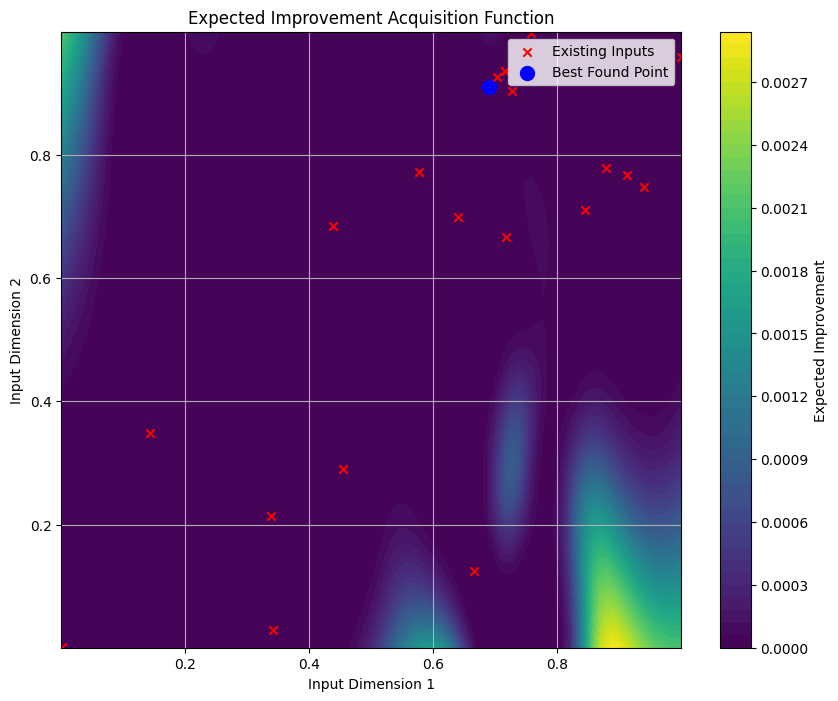

Next query point: [np.float64(0.888888111111111), np.float64(1e-06)]


In [ ]:
!pip install scikit-optimize==0.9.0

import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from skopt.acquisition import gaussian_ei
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# 1. Load updated data
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# 2. Define search space with a small buffer
epsilon = 1e-6 # A small value to avoid exact boundaries
space = [Real(0 + epsilon, 1 - epsilon, name='x1'), Real(0 + epsilon, 1 - epsilon, name='x2')]

# 3. Define objective function (replace with your actual model evaluation if you have one)
@use_named_args(space)
def objective_function(**params):
    x = np.array([params['x1'], params['x2']])
    # Use 'nearest' method to avoid NaN values for points outside the convex hull
    output = griddata(updated_inputs, updated_outputs, x, method='nearest')

    # Ensure output is a scalar by taking the first element if it's an array
    # or returning 0 if it's NaN
    if np.isscalar(output):
        return -output  # Negate for minimization
    elif np.isnan(output):  # Handle NaN values
        return 0  # You might choose a different value for NaN cases
    else:
        return -output.item(0) # Take the first element and negate for minimization


# 4. Run Bayesian Optimization to get the current model
# We only run it for the number of existing points to get the model for acquisition function calculation
result = gp_minimize(
    objective_function,
    space,
    n_calls=len(updated_inputs),
    random_state=0,
    x0=updated_inputs.tolist(),
    y0=-updated_outputs,
    acq_func="EI",
    xi=0.05,
)

# --- Visualize Acquisition Function and Get Next Query ---

# Create a grid of points to evaluate the acquisition function within the slightly adjusted space
x1_values = np.linspace(0 + epsilon, 1 - epsilon, 100)
x2_values = np.linspace(0 + epsilon, 1 - epsilon, 100)
X1, X2 = np.meshgrid(x1_values, x2_values)
points = np.array([X1.ravel(), X2.ravel()]).T

# Calculate the Expected Improvement (EI) for each point
ei_values = gaussian_ei(points, result.models[-1], result.fun, xi=0.05)

# Reshape EI values to match the grid shape
EI = ei_values.reshape(X1.shape)

# Plot the acquisition function (EI) - Optional visualization
plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, EI, levels=50, cmap='viridis')
plt.colorbar(label='Expected Improvement')
plt.scatter(updated_inputs[:, 0], updated_inputs[:, 1], c='red', marker='x', label='Existing Inputs')
plt.scatter(result.x[0], result.x[1], c='blue', marker='o', s=100, label='Best Found Point')
plt.xlabel('Input Dimension 1')
plt.ylabel('Input Dimension 2')
plt.title('Expected Improvement Acquisition Function')
plt.legend()
plt.grid(True)
plt.show()

# --- Get Next Query ---
# Find the maximum EI value and its index
max_ei_index = np.unravel_index(np.argmax(EI), EI.shape)

# Get the corresponding x1 and x2 values for the next query
next_x1 = x1_values[max_ei_index[1]]
next_x2 = x2_values[max_ei_index[0]]

# Create the next query point
next_query = [next_x1, next_x2]

# Print the next query point
print("Next query point:", next_query)

In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Print the loaded data
print("Updated Inputs:\n", updated_inputs)
print("\nUpdated Outputs:\n", updated_outputs)

Updated Inputs:
 [[6.65799580e-01 1.23969128e-01]
 [8.77790989e-01 7.78627501e-01]
 [1.42699074e-01 3.49005131e-01]
 [8.45275429e-01 7.11120267e-01]
 [4.54647141e-01 2.90455180e-01]
 [5.77712844e-01 7.71973184e-01]
 [4.38166062e-01 6.85018257e-01]
 [3.41749593e-01 2.86977198e-02]
 [3.38648157e-01 2.13867246e-01]
 [7.02636557e-01 9.26564198e-01]
 [7.15678000e-01 9.35678000e-01]
 [6.40000000e-01 7.00000000e-01]
 [7.15678000e-01 9.35678000e-01]
 [9.99999000e-01 9.59595000e-01]
 [9.39393000e-01 7.47474000e-01]
 [7.27349000e-01 9.03440000e-01]
 [5.07000000e-04 1.01400000e-03]
 [7.17171000e-01 6.66666000e-01]
 [6.90000000e-01 9.10000000e-01]
 [9.12000000e-01 7.68000000e-01]
 [7.57624825e-01 9.98489009e-01]]

Updated Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.60094184  0.24762915
  0.60094184  0.05322359 -0.00187132  0.5967699  -0.01977609  0.55900498
  0.66660275  0.02837605  0.35546536]


In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the index of the maximum output (highest log-likelihood)
# np.argmax finds the index of the maximum value in an array.
best_index = np.argmax(updated_outputs)

# Select the corresponding input
# We use the index found in the previous step to get the input from the updated_inputs array.
best_input = updated_inputs[best_index]

# Print the best input
print("Best updated input (corresponding to highest log-likelihood):", best_input)

Best updated input (corresponding to highest log-likelihood): [0.69 0.91]


In [ ]:
import numpy as np

# Load the updated inputs and outputs
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# Find the index of the maximum output (highest log-likelihood)
best_index = np.argmax(updated_outputs)

# Select the corresponding input
best_input = updated_inputs[best_index]

# Get the corresponding output
best_output = updated_outputs[best_index]

# Print the best input and its corresponding output
print("Best updated input (corresponding to highest log-likelihood):", best_input)
print("Corresponding highest log-likelihood:", best_output)

Best updated input (corresponding to highest log-likelihood): [0.69 0.91]
Corresponding highest log-likelihood: 0.6666027531552023


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.3/100.3 kB 2.8 MB/s eta 0:00:00
Running Bayesian Optimization with xi = 0.05


/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:449: UserWarning: The objective has been evaluated at this point before.
  warnings.warn("The objective has been evaluated "



Results for xi = 0.05:
Best parameters: [0.69, 0.91]
Best log-likelihood: 0.6666027531552023


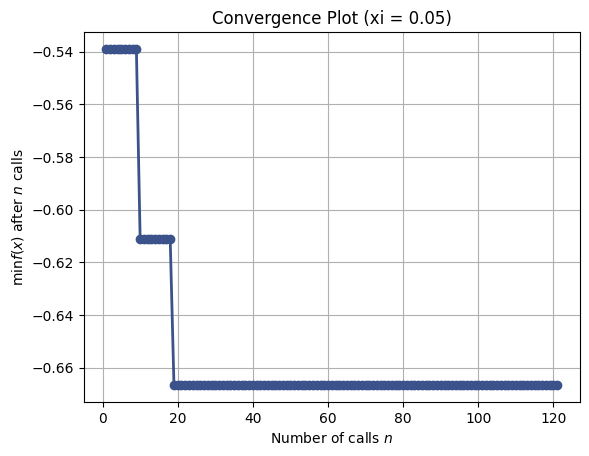


Next query point suggested by Bayesian Optimization: [np.float64(0.696969696969697), np.float64(0.4040404040404041)]


In [ ]:
!pip install scikit-optimize==0.9.0

import numpy as np
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from skopt.acquisition import gaussian_ei  # Import Expected Improvement
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# --- 1. Load Updated Data ---
updated_inputs = np.load('/content/updated_inputs.npy')
updated_outputs = np.load('/content/updated_outputs.npy')

# --- 2. Define Search Space ---
space = [Real(0, 1, name='x1'), Real(0, 1, name='x2')]

# --- 3. Define Objective Function (Replace with your model evaluation) ---
@use_named_args(space)
def objective_function(**params):
    x = np.array([params['x1'], params['x2']])
    # Replace this with your actual machine learning model evaluation
    # The model should take 'x' as input and return a single scalar value (e.g., log-likelihood)
    output = griddata(updated_inputs, updated_outputs, x, method='nearest') # Example using interpolation
    if np.isscalar(output):
        return -output  # Negate for minimization
    elif np.isnan(output):
        return 0  # Handle NaN values
    else:
        return -output.item(0) # Negate for minimization

# --- 4. Run Bayesian Optimization with a specific 'xi' ---

# Experiment with different xi values (e.g., 0.01, 0.05, 0.1)
# Let's run with xi = 0.05 first as you had it
xi_value = 0.05

print(f"Running Bayesian Optimization with xi = {xi_value}")

result = gp_minimize(
    objective_function,
    space,
    n_calls=100,  # Number of iterations
    random_state=0,
    x0=updated_inputs.tolist(),  # Initial points
    y0=-updated_outputs,         # Initial outputs (negated for minimization)
    acq_func="EI",  # Acquisition function (Expected Improvement)
    xi=xi_value,        # Exploration parameter
)

# --- 5. Analyze and Visualize Results ---

print(f"\nResults for xi = {xi_value}:")
print("Best parameters:", result.x)
print("Best log-likelihood:", -result.fun)  # Negate back to get log-likelihood

plot_convergence(result)
plt.title(f'Convergence Plot (xi = {xi_value})')
plt.show()

# --- Example of running with a different xi value (Optional) ---

# xi_value_experiment = 0.1
# print(f"\nRunning Bayesian Optimization with xi = {xi_value_experiment}")

# result_experiment = gp_minimize(
#     objective_function,
#     space,
#     n_calls=100,
#     random_state=0,
#     x0=updated_inputs.tolist(),
#     y0=-updated_outputs,
#     acq_func="EI",
#     xi=xi_value_experiment,
# )

# print(f"\nResults for xi = {xi_value_experiment}:")
# print("Best parameters:", result_experiment.x)
# print("Best log-likelihood:", -result_experiment.fun)

# plot_convergence(result_experiment)
# plt.title(f'Convergence Plot (xi = {xi_value_experiment})')
# plt.show()

# --- Get Next Query based on the latest optimization result ---

# Create a grid of points to evaluate the acquisition function
x1_values = np.linspace(0, 1, 100)
x2_values = np.linspace(0, 1, 100)
X1, X2 = np.meshgrid(x1_values, x2_values)
points = np.array([X1.ravel(), X2.ravel()]).T

# Calculate the Expected Improvement (EI) for each point
# Use the model from the latest optimization result
ei_values = gaussian_ei(points, result.models[-1], result.fun, xi=xi_value)

# Reshape EI values to match the grid shape
EI = ei_values.reshape(X1.shape)

# Find the maximum EI value and its index
max_ei_index = np.unravel_index(np.argmax(EI), EI.shape)

# Get the corresponding x1 and x2 values for the next query
next_x1 = x1_values[max_ei_index[1]]
next_x2 = x2_values[max_ei_index[0]]

# Create the next query point
next_query = [next_x1, next_x2]

# Print the next query point
print("\nNext query point suggested by Bayesian Optimization:", next_query)